# Stochastic antibiotic environments

This notebook analyzes plasmid dynamics under temporally correlated stochastic antibiotic exposure. It first performs a single-strain stochastic screen across the parameterized strain set, then repeats the time-series analyses at the complete-community level. The goal is to separate the effect of antibiotic amplitude from the effect of temporal correlation structure.

In [5]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Axis labels
    "axes.labelsize": 16,

    # Plot titles
    "axes.titlesize": 16,
    "figure.titlesize": 16,

    # Legends
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,

    # General text
    "font.size": 14,

    # Optional: make saved figures cleaner
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

plt.rcParams.update({
    "axes.linewidth": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "legend.frameon": False,
})

## Simulation parameters

In [7]:
extinction_threshold = 1e5

max_noise_reps = 100

noise_ids = [
    "violet_noise",
    "blue_noise",
    "white_noise",
    "pink_noise",
    "brownian_noise",
]

noise_color_map = {
    "violet_noise": "#7B2CBF",    # violet
    "blue_noise": "#1F77B4",      # blue
    "white_noise": "#BDBDBD",     # light gray for visibility
    "pink_noise": "#E377C2",      # pink
    "brownian_noise": "#8C564B",  # brown
}

noise_label_map = {
    "violet_noise": "Violet",
    "blue_noise": "Blue",
    "white_noise": "White",
    "pink_noise": "Pink",
    "brownian_noise": "Brownian",
}


Amin=0
Amax=1024
num_days = 64


## Repository paths

Stochastic simulations are organized by antibiotic amplitude and experiment duration. Each batch writes to case-specific `runs_A*_T*` and `figures_A*_T*` directories, which allows results from different values of $A_{\max}$ and simulation length to be compiled later without recomputation.


In [8]:
PROJECT_ROOT = Path.cwd()

codePath = PROJECT_ROOT / 'code'
dataPath = PROJECT_ROOT / 'data'
envPath = PROJECT_ROOT / 'env'
runPath = PROJECT_ROOT / f"runs/A{Amax:g}_T{num_days:g}"
figPath = PROJECT_ROOT / f"figures/A{Amax:g}_T{num_days:g}"

for p in [runPath, figPath]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('codePath     =', codePath)
print('dataPath     =', dataPath)
print('runPath      =', runPath)
print('figPath      =', figPath)


Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT
codePath     = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/code
dataPath     = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/data
runPath      = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A1024_T64
figPath      = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A1024_T64


In [9]:

REPO = False

if REPO:
    repo_url = 'https://github.com/ccg-esb-lab/plasmidNoise.git'
    repo_name = 'plasmidNoise'

    if not Path(repo_name).exists():
        !git clone {repo_url}

    PROJECT_ROOT = Path(repo_name).resolve()
    codePath = PROJECT_ROOT / 'code'
    dataPath = PROJECT_ROOT / 'data'
    envPath = PROJECT_ROOT / 'env'
    runPath = PROJECT_ROOT / f"runs/A{Amax:g}_T{num_days:g}"
    figPath = PROJECT_ROOT / f"figures/A{Amax:g}_T{num_days:g}"

    for p in [runPath, figPath]:
        p.mkdir(parents=True, exist_ok=True)

if str(codePath) not in sys.path:
    sys.path.insert(0, str(codePath))

print('Files in codePath:')
for p in sorted(codePath.glob('*.py')):
    print('  ', p.name)


Files in codePath:
   plasmidNoise_model.py
   plasmidNoise_plotter.py


## Model modules

The stochastic notebook uses the same plasmid population model as the constant and periodic analyses. Stochasticity enters only through the antibiotic control vector applied at the beginning of each serial-transfer cycle.


In [10]:
import plasmidNoise_model as pn
import plasmidNoise_plotter as pp


## Parameterized strain set

The parameter table defines the host-dependent plasmid fitness landscape. Stochastic environments are used to test how temporal correlations in antibiotic exposure interact with these strain-specific plasmid costs, susceptibilities, and transfer phenotypes.


In [11]:
params_csv = dataPath / 'pOXA48_model_params.csv'
model_params = pn.load_parameter_table(params_csv)
model_params.head()


,strain,display_name,species,color,r_p,affinity_p,k_star_p,r_0,affinity_0,k_star_0,lambda_loss,gamma,Km_p,Vmax_p,alpha_p,k_p,Km_0,Vmax_0,alpha_0,k_0
0,C001,PF_EC01,E,#d60000,984410100.0,4.900000e-10,0.000488,877563800.0,5.280000e-10,0.000244,0.02,0.0,1.0,4.900000e-10,1.000000e-12,0.015625,1.0,5.280000e-10,1.000000e-10,0.03125
1,C002,PF_EC02,E,#018700,550386500.0,7.600000e-10,0.062500,678608700.0,6.650000e-10,0.000244,0.02,0.0,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.650000e-10,1.000000e-10,0.03125
2,C006,PF_EC03,E,#b500ff,890018480.0,7.600000e-10,0.062500,815145500.0,6.540000e-10,0.000122,0.02,0.0,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.540000e-10,1.000000e-10,0.06250
3,C011,PF_EC04,E,#05acc6,776372125.0,8.370000e-10,0.000488,770241720.0,6.580000e-10,0.000244,0.02,0.0,1.0,8.370000e-10,1.000000e-12,0.015625,1.0,6.580000e-10,1.000000e-10,0.03125
4,C012,PF_EC05,E,#97ff00,772746800.0,6.300000e-10,0.062500,641598800.0,7.830000e-10,0.000122,0.02,0.0,1.0,6.300000e-10,1.000000e-12,0.000122,1.0,7.830000e-10,1.000000e-10,0.06250


## Stochastic treatment design

Antibiotic environments are generated from externally stored fractional Gaussian noise realizations. Each realization is resampled to the number of transfers and normalized to the interval $[A_{\min}, A_{\max}]$. The noise classes therefore share the same concentration range but differ in temporal correlation structure.


In [12]:
def load_stochastic_environment(
    envPath,
    noise_id,
    rep_id,
    n_transfers,
    Amin=0.0,
    Amax=4.0,
    mode="normalize",
    file_suffix=".csv",
):
    """
    Load a stochastic antibiotic environment from file.

    Expected file:
    env/<noise_id>/<noise_id>_<rep_id>.csv

    Expected file format:
    column 0 = noise value
    column 1 = time

    Returns a numeric environment dataframe with columns:
    transfer, A
    """
    envPath = Path(envPath)
    rep_id_str = str(rep_id)

    file_path = envPath / noise_id / f"{noise_id}_{rep_id_str}{file_suffix}"

    if not file_path.exists():
        raise FileNotFoundError(f"Environment file not found: {file_path}")

    raw = pd.read_csv(
        file_path,
        header=None,
        names=["noise", "time"],
    )

    raw = raw.sort_values("time").reset_index(drop=True)

    noise = raw["noise"].to_numpy(dtype=float)
    time = raw["time"].to_numpy(dtype=float)

    time_min = time.min()
    time_max = time.max()

    if time_max == time_min:
        raise ValueError("Time column has zero range.")

    time_scaled = (time - time_min) / (time_max - time_min)

    transfer = np.arange(n_transfers)
    transfer_scaled = np.linspace(0, 1, n_transfers)

    sampled_noise = np.interp(
        transfer_scaled,
        time_scaled,
        noise,
    )

    if mode == "normalize":
        x_min = sampled_noise.min()
        x_max = sampled_noise.max()

        if x_max == x_min:
            A = np.full_like(sampled_noise, 0.5 * (Amin + Amax))
        else:
            A = Amin + (sampled_noise - x_min) / (x_max - x_min) * (Amax - Amin)

    elif mode == "clip":
        A = np.clip(sampled_noise, Amin, Amax)

    elif mode == "shift_scale":
        midpoint = 0.5 * (Amin + Amax)
        amplitude = 0.5 * (Amax - Amin)

        sd = sampled_noise.std()

        if sd == 0:
            A = np.full_like(sampled_noise, midpoint)
        else:
            z = sampled_noise / sd
            A = midpoint + amplitude * z
            A = np.clip(A, Amin, Amax)

    else:
        raise ValueError("mode must be 'normalize', 'clip', or 'shift_scale'.")

    # Important:
    # only numeric columns should be passed to the simulator.
    env = pd.DataFrame(
        {
            "transfer": transfer,
            "A": A,
        }
    )

    return env


In [13]:
exp5_run_path = runPath / "experiment5_stochastic_environments"
exp5_run_path.mkdir(parents=True, exist_ok=True)

exp5_fig_path = figPath / "experiment5_stochastic_environments"
exp5_fig_path.mkdir(parents=True, exist_ok=True)

complete_community_members = sorted(model_params["strain"].unique())

experiment5_config = pn.SimulationConfig(
    season_duration=24.0,
    points_per_season=121,
    R0=1.0,
    B0_total=1e6,
    dilution=0.01,
    extinction_threshold=extinction_threshold,
    solver_method="LSODA",
    uptake_mode="monod",
    initial_plasmid_fraction=1.0,
)


## Shared stochastic simulation helpers

The following functions load stochastic antibiotic histories, run or reload saved simulations, extract endpoint summaries, and plot representative trajectories. The same output structure is used for single-strain and complete-community simulations.


In [14]:
def plot_stochastic_replicate_outcomes(
    exp5_df,
    noise_id=None,
    save_path=None,
):
    """
    Plot stochastic replicate outcomes for one noise type.

    Panels:
    1. Final plasmid fraction
    2. Final total bacterial density
    3. Final plasmid-bearing and plasmid-free densities

    Parameters
    ----------
    exp5_df : pandas.DataFrame
        Summary dataframe for one noise type.

    noise_id : str, optional
        Name of the noise type, used in the figure title.

    save_path : str or Path, optional
        If provided, save figure to this path.

    Returns
    -------
    fig, axes
    """

    df = exp5_df.copy().reset_index(drop=True)

    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8))

    x = np.arange(len(df))

    # Panel 1: plasmid fraction
    axes[0].scatter(
        x,
        df["plasmid_fraction"],
        c="black",
        alpha=0.7,
    )
    axes[0].set_ylabel("Final plasmid fraction")
    axes[0].set_xlabel("Stochastic replicate")
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].set_title("Plasmid fraction")

    # Panel 2: total density
    axes[1].scatter(
        x,
        df["bacterial_density"],
        c="black",
        alpha=0.7,
    )
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Final total density")
    axes[1].set_xlabel("Stochastic replicate")
    axes[1].set_title("Total density")

    # Panel 3: subpopulation densities
    axes[2].scatter(
        x,
        df["Bp_final"],
        c="black",
        alpha=0.7,
        label=r"$B_p$",
    )
    axes[2].scatter(
        x,
        df["Bempty_final"],
        alpha=0.7,
        label=r"$B_\emptyset$",
    )
    axes[2].set_yscale("log")
    axes[2].set_ylabel("Final density")
    axes[2].set_xlabel("Stochastic replicate")
    axes[2].set_title("Subpopulations")
    axes[2].legend(frameon=False)

    if noise_id is None:
        if "noise_id" in df.columns and df["noise_id"].nunique() == 1:
            noise_id = df["noise_id"].iloc[0]
        else:
            noise_id = "stochastic environments"

    fig.suptitle(f"Stochastic environments: {noise_id}", y=1.05)
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, axes


In [15]:

def plot_stochastic_environment(
    stochastic_env,
    noise_id=None,
    rep_id=None,
    save_path=None,
):
    """
    Plot one stochastic antibiotic environment.

    Parameters
    ----------
    stochastic_env : pandas.DataFrame
        Environment dataframe with columns 'transfer' and 'A'.

    noise_id : str, optional
        Noise type used in the title.

    rep_id : str or int, optional
        Replicate ID used in the title.

    save_path : str or Path, optional
        If provided, save figure to this path.

    Returns
    -------
    fig, ax
    """

    fig, ax = plt.subplots(figsize=(7.0, 3.4))

    ax.plot(
        stochastic_env["transfer"],
        stochastic_env["A"],
        marker="o",
        linewidth=1.8,
    )

    ax.set_xlabel("Transfer / day")
    ax.set_ylabel("Antibiotic concentration")

    if noise_id is not None and rep_id is not None:
        ax.set_title(f"Stochastic environment: {noise_id}, rep {rep_id}")
    elif noise_id is not None:
        ax.set_title(f"Stochastic environment: {noise_id}")
    else:
        ax.set_title("Stochastic environment")

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_stochastic_environment_stack(
    noise_ids,
    all_rep_ids,
    highlight_rep_ids=None,
    *,
    envPath,
    Amin,
    Amax,
    num_days,
    noise_color_map,
    noise_label_map=None,
    mode="normalize",
    save_path=None,
    figsize_per_panel=(6.0, 1.2),
    sharex=True,
    individual_alpha=0.20,
    individual_linewidth=1.0,
    highlight_alpha=1.0,
    highlight_linewidth=2.0,
    mean_linewidth=2.5,
    plot_mean=True,
    individual_marker=None,
    highlight_marker=None,
    mean_marker=None,
):
    """
    Plot stochastic antibiotic environments as a compact vertical stack.

    Parameters
    ----------
    noise_ids : list
        One noise type per subplot row.

    all_rep_ids : list
        Same length as noise_ids.
        Each element can be:
            - a single rep_id
            - a list of rep_ids
        These are all plotted in transparent color.

    highlight_rep_ids : list or None
        Same length as noise_ids.
        Each element can be:
            - None
            - a single rep_id
            - a list of rep_ids
        These are replotted on top in opaque color.

    Returns
    -------
    fig, axes, loaded_envs
    """

    if len(noise_ids) != len(all_rep_ids):
        raise ValueError("noise_ids and all_rep_ids must have the same length.")

    if highlight_rep_ids is None:
        highlight_rep_ids = [None] * len(noise_ids)

    if len(noise_ids) != len(highlight_rep_ids):
        raise ValueError("noise_ids and highlight_rep_ids must have the same length.")

    if noise_label_map is None:
        noise_label_map = {noise_id: noise_id for noise_id in noise_ids}

    def _normalize_rep_entry(rep_entry):
        if rep_entry is None:
            return []
        if isinstance(rep_entry, (str, int)):
            return [str(rep_entry)]
        return [str(x) for x in rep_entry]

    n = len(noise_ids)

    fig, axes = plt.subplots(
        n,
        1,
        figsize=(figsize_per_panel[0], figsize_per_panel[1] * n),
        sharex=sharex,
        squeeze=False,
        gridspec_kw={"hspace": 0.0},
    )

    axes = axes.flatten()
    loaded_envs = {}

    for i, (ax, noise_id, rep_entry_all, rep_entry_highlight) in enumerate(
        zip(axes, noise_ids, all_rep_ids, highlight_rep_ids)
    ):

        rep_list_all = _normalize_rep_entry(rep_entry_all)
        rep_list_highlight = _normalize_rep_entry(rep_entry_highlight)
        rep_set_highlight = set(rep_list_highlight)

        color = noise_color_map.get(noise_id, "black")
        label = noise_label_map.get(noise_id, noise_id)

        env_rows = []
        loaded_for_this_noise = {}

        # ------------------------------------------------------------
        # Load all replicates
        # ------------------------------------------------------------
        for rep_id in rep_list_all:
            try:
                stochastic_env = load_stochastic_environment(
                    envPath=envPath,
                    noise_id=noise_id,
                    rep_id=rep_id,
                    n_transfers=num_days,
                    Amin=Amin,
                    Amax=Amax,
                    mode=mode,
                )
            except Exception as e:
                print(f"Skipping {noise_id} rep {rep_id}: {e}")
                continue

            loaded_envs[(noise_id, rep_id)] = stochastic_env
            loaded_for_this_noise[rep_id] = stochastic_env

            env_plot = stochastic_env.copy()
            env_plot["rep_id"] = rep_id
            env_rows.append(env_plot)

        # ------------------------------------------------------------
        # Plot all replicates with transparency
        # ------------------------------------------------------------
        for rep_id, env_plot in loaded_for_this_noise.items():
            ax.plot(
                env_plot["transfer"],
                env_plot["A"],
                color=color,
                alpha=individual_alpha,
                linewidth=individual_linewidth,
                marker=individual_marker,
                zorder=1,
            )

        # ------------------------------------------------------------
        # Replot highlighted subset in opaque color
        # ------------------------------------------------------------
        for rep_id in rep_list_highlight:
            if rep_id not in loaded_for_this_noise:
                continue

            env_plot = loaded_for_this_noise[rep_id]

            ax.plot(
                env_plot["transfer"],
                env_plot["A"],
                color=color,
                alpha=highlight_alpha,
                linewidth=highlight_linewidth,
                marker=highlight_marker,
                zorder=4,
            )

        # ------------------------------------------------------------
        # Mean trajectory across all loaded replicates
        # ------------------------------------------------------------
        if plot_mean and len(env_rows) > 0:
            env_df = pd.concat(env_rows, ignore_index=True)

            mean_df = (
                env_df
                .groupby("transfer", as_index=False)["A"]
                .mean()
                .sort_values("transfer")
            )

            ax.plot(
                mean_df["transfer"],
                mean_df["A"],
                color="black",
                linewidth=mean_linewidth,
                marker=mean_marker,
                zorder=6,
            )

        # ------------------------------------------------------------
        # Formatting
        # ------------------------------------------------------------
        ax.set_ylabel("A(n)")

        ax.text(
            0.01,
            0.80,
            f"{label}",
            transform=ax.transAxes,
            ha="left",
            va="center",
            fontsize=12,
        )

        ax.set_yticks([Amin, Amax])
        ax.set_ylim(
            Amin - 0.15 * (Amax - Amin),
            Amax + 0.15 * (Amax - Amin),
        )
        ax.set_xlim([0, num_days - 1])

        if i < n - 1:
            ax.tick_params(axis="x", labelbottom=False)
            ax.set_xlabel("")

    axes[-1].set_xlabel("Time (n)")

    fig.subplots_adjust(
        hspace=0.0,
        top=0.98,
        bottom=0.10,
        left=0.12,
        right=0.98,
    )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, axes, loaded_envs

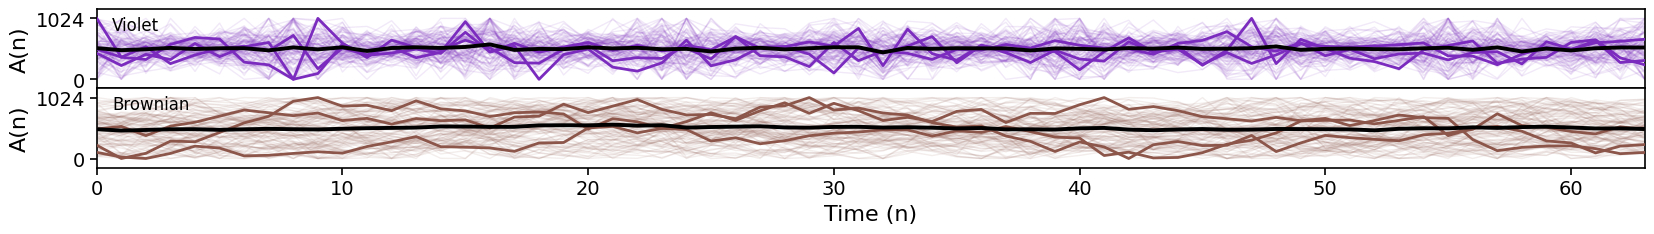

In [17]:
noise_ids_to_plot = [
    "violet_noise",
    "brownian_noise",
]

all_rep_ids_to_plot = [
    [str(i) for i in range(100)]
    for _ in noise_ids_to_plot
]

highlight_rep_ids_to_plot = [
    ["0", "1", "2"],
    ["0", "1", "2"],
]

fig, axes, loaded_envs = plot_stochastic_environment_stack(
    noise_ids_to_plot,
    all_rep_ids_to_plot,
    highlight_rep_ids=highlight_rep_ids_to_plot,
    envPath=envPath,
    Amin=Amin,
    Amax=Amax,
    num_days=num_days,
    noise_color_map=noise_color_map,
    noise_label_map=noise_label_map,
    mode="normalize",
    figsize_per_panel=(18.0, 0.9),
    individual_alpha=0.10,
    individual_linewidth=1.0,
    highlight_alpha=1.0,
    highlight_linewidth=2.0,
    mean_linewidth=2.8,
    plot_mean=True,
    individual_marker=None,
    highlight_marker=None,
    mean_marker=None,
)

plt.show()

In [18]:
def run_stochastic_noise_batch(
    noise_id,
    *,
    envPath,
    exp5_run_path,
    model_params,
    complete_community_members,
    experiment5_config,
    num_days,
    Amin,
    Amax,
    max_noise_reps=None,
    environment_mode="normalize",
):
    """
    Run/load stochastic-environment simulations for one noise type.

    Reads files matching:
        env/<noise_id>/<noise_id>_*.csv

    For each file:
        load environment -> run if missing -> save -> load -> summarize

    Returns
    -------
    exp5_df : pandas.DataFrame
        Summary table for this noise_id.
    exp5_loaded_results : list
        Loaded simulation objects.
    """

    noise_dir = Path(envPath) / noise_id
    noise_files = sorted(noise_dir.glob(f"{noise_id}_*.csv"))
    print("=" * 80)
    print(f"Noise type: {noise_id}")
    print("**Noise directory:", noise_dir)
    print("Files found:", len(noise_files))

    if len(noise_files) == 0:
        print(f"No files found for {noise_id}. Skipping.")
        return pd.DataFrame(), []

    if max_noise_reps is not None:
        noise_files = noise_files[:max_noise_reps]
        print("Files selected after cap:", len(noise_files))

    exp5_rows = []
    exp5_loaded_results = []

    run_counter = 0
    skip_counter = 0

    for i, file_path in enumerate(noise_files, start=1):

        # Extract rep_id from filename:
        # white_noise_001.csv -> 001
        rep_id = file_path.stem.replace(f"{noise_id}_", "")

        stochastic_env = load_stochastic_environment(
            envPath=envPath,
            noise_id=noise_id,
            rep_id=rep_id,
            n_transfers=num_days,
            Amin=Amin,
            Amax=Amax,
            mode=environment_mode,
        )


        #fig, ax = plot_stochastic_environment(
        #    stochastic_env,
        #    noise_id=noise_id,
        #    rep_id=rep_id,
        #)
        #plt.show()
        ##    save_path=exp5_fig_path / f"stochastic_environment_{noise_id}_rep{rep_id}.png",

        # Important:
        # simulator should receive only numeric columns.
        stochastic_env_for_sim = stochastic_env[["transfer", "A"]].copy()
        stochastic_env_for_sim["transfer"] = stochastic_env_for_sim["transfer"].astype(float)
        stochastic_env_for_sim["A"] = stochastic_env_for_sim["A"].astype(float)

        run_id = (
            f"exp5_completeCommunity_"
            f"{noise_id}_rep{rep_id}_Amin{Amin:g}_Amax{Amax:g}_N{num_days}"
        )

        save_file = exp5_run_path / f"{run_id}.pkl.gz"

        print(
            f"[{i:03d}/{len(noise_files):03d}] "
            f"noise_id={noise_id} | rep_id={rep_id}"
        )

        if save_file.exists():
            print("    found saved simulation, loading...")
            loaded = pn.load_simulation(save_file)
            skip_counter += 1

        else:
            print("    saved simulation not found, running...")

            result = pn.simulate_serial_transfers(
                model_params,
                members=complete_community_members,
                environment=stochastic_env_for_sim,
                config=experiment5_config,
                run_id=run_id,
                metadata={
                    "experiment": "Experiment 5",
                    "description": "Complete community in stochastic antibiotic environment",
                    "noise_id": noise_id,
                    "rep_id": rep_id,
                    "Amin": Amin,
                    "Amax": Amax,
                    "n_transfers": num_days,
                    "n_members": len(complete_community_members),
                    "members": complete_community_members,
                    "environment_mode": environment_mode,
                    "source_file": str(file_path),
                },
            )

            pn.save_simulation(result, save_file)
            loaded = pn.load_simulation(save_file)
            run_counter += 1

        exp5_loaded_results.append(loaded)

        final_state = extract_final_community_state(
            loaded,
            density_extinction_threshold=experiment5_config.extinction_threshold,
        )


        exp5_rows.append(
            {
                "run_id": run_id,
                "noise_id": noise_id,
                "rep_id": rep_id,
                "Amin": Amin,
                "Amax": Amax,
                "n_transfers": num_days,
                "n_members": len(complete_community_members),
                "plasmid_fraction": final_state["plasmid_frequency"],
                "bacterial_density": final_state["Btotal_final"],
                "Bp_final": final_state["Bp_final"],
                "Bempty_final": final_state["Bempty_final"],
                "save_file": str(save_file),
                "source_file": str(file_path),
            }
        )

        print(
            f"    result | "
            f"plasmid_fraction={final_state['plasmid_frequency']:.3f} | "
            f"bacterial_density={final_state['Btotal_final']:.3e} | "
            f"Bp={final_state['Bp_final']:.3e} | "
            f"Bempty={final_state['Bempty_final']:.3e}"
        )

    exp5_df = pd.DataFrame(exp5_rows)

    if len(exp5_df) > 0:
        exp5_df = exp5_df.sort_values(["noise_id", "rep_id"]).reset_index(drop=True)

        summary_file = exp5_run_path / f"experiment5_{noise_id}_summary.csv"
        exp5_df.to_csv(summary_file, index=False)

        print("-" * 80)
        print(f"{noise_id}")
        #print("Summary rows:", len(exp5_df))
        print("New simulations run:", run_counter)
        print("Saved simulations loaded:", skip_counter)
        print("Saved summary table to:", summary_file)


        fig, axes = plot_stochastic_replicate_outcomes(
            exp5_df,
            noise_id=noise_id,
        )
        plt.show()


    return exp5_df, exp5_loaded_results


In [19]:
def extract_final_community_state(
    result,
    density_extinction_threshold=extinction_threshold,
):
    """
    Extract final Bp, Bempty, Btotal, and plasmid frequency
    from a loaded simulation result.

    Densities below density_extinction_threshold are treated as extinct.
    """
    tr = result.transfers[-1]
    y = tr["y"]
    n = len(result.members)

    Bp_final_by_strain = y[2 : 2 + n, -1].copy()
    Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

    Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
    Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

    Bp_final = Bp_final_by_strain.sum()
    Bempty_final = Bempty_final_by_strain.sum()
    Btotal_final = Bp_final + Bempty_final

    if Btotal_final > 0:
        plasmid_frequency = Bp_final / Btotal_final
    else:
        plasmid_frequency = np.nan

    return {
        "Bp_final": Bp_final,
        "Bempty_final": Bempty_final,
        "Btotal_final": Btotal_final,
        "plasmid_frequency": plasmid_frequency,
    }
def extract_daily_strain_frequencies(
    result,
    density_extinction_threshold=extinction_threshold,
):
    """
    Extract daily final frequencies of each strain from a simulation.

    For each transfer/day, the final strain density is:

        Btotal_i = Bp_i + Bempty_i

    and the strain frequency is:

        frequency_i = Btotal_i / sum_j Btotal_j

    Densities below density_extinction_threshold are treated as extinct.

    Returns
    -------
    df : pandas.DataFrame
        One row per strain per transfer.
    """

    rows = []

    members = list(result.members)
    n = len(members)

    for transfer_idx, tr in enumerate(result.transfers):
        y = tr["y"]

        Bp_final_by_strain = y[2 : 2 + n, -1].copy()
        Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

        # Apply density-based extinction threshold
        Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
        Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

        Btotal_final_by_strain = Bp_final_by_strain + Bempty_final_by_strain
        community_total = Btotal_final_by_strain.sum()

        A_initial = tr.get("A_initial", np.nan)

        for strain, Bp_i, Bempty_i, Btotal_i in zip(
            members,
            Bp_final_by_strain,
            Bempty_final_by_strain,
            Btotal_final_by_strain,
        ):
            strain_frequency = np.nan
            strain_plasmid_fraction = np.nan

            if community_total > 0:
                strain_frequency = Btotal_i / community_total

            if Btotal_i > 0:
                strain_plasmid_fraction = Bp_i / Btotal_i

            rows.append(
                {
                    "run_id": result.run_id,
                    "transfer": transfer_idx,
                    "day": transfer_idx + 1,
                    "A_initial": A_initial,
                    "strain": strain,
                    "Bp_final": Bp_i,
                    "Bempty_final": Bempty_i,
                    "Btotal_final": Btotal_i,
                    "community_total_final": community_total,
                    "strain_frequency": strain_frequency,
                    "strain_plasmid_fraction": strain_plasmid_fraction,
                }
            )

    df = pd.DataFrame(rows)

    return df

from matplotlib.lines import Line2D


def extract_daily_strain_subpopulation_frequencies(
    result,
    density_extinction_threshold=1.0,
):
    """
    Extract daily final frequencies and densities of each strain subpopulation.

    For each transfer/day:
        Bp_frequency_i     = Bp_i / community_total
        Bempty_frequency_i = Bempty_i / community_total

    where:
        community_total = sum_i (Bp_i + Bempty_i)

    Densities below density_extinction_threshold are treated as extinct.
    """

    rows = []

    members = list(result.members)
    n = len(members)

    for transfer_idx, tr in enumerate(result.transfers):
        y = tr["y"]

        Bp_final_by_strain = y[2 : 2 + n, -1].copy()
        Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

        # Apply density-based extinction threshold
        Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
        Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

        Btotal_final_by_strain = Bp_final_by_strain + Bempty_final_by_strain
        community_total = Btotal_final_by_strain.sum()

        A_initial = tr.get("A_initial", np.nan)

        for strain, Bp_i, Bempty_i, Btotal_i in zip(
            members,
            Bp_final_by_strain,
            Bempty_final_by_strain,
            Btotal_final_by_strain,
        ):

            if community_total > 0:
                Bp_frequency = Bp_i / community_total
                Bempty_frequency = Bempty_i / community_total
                strain_frequency = Btotal_i / community_total
            else:
                Bp_frequency = np.nan
                Bempty_frequency = np.nan
                strain_frequency = np.nan

            if Btotal_i > 0:
                strain_plasmid_fraction = Bp_i / Btotal_i
            else:
                strain_plasmid_fraction = np.nan

            rows.append(
                {
                    "run_id": result.run_id,
                    "transfer": transfer_idx,
                    "day": transfer_idx + 1,
                    "A_initial": A_initial,
                    "strain": strain,
                    "Bp_final": Bp_i,
                    "Bempty_final": Bempty_i,
                    "Btotal_final": Btotal_i,
                    "community_total_final": community_total,
                    "Bp_frequency": Bp_frequency,
                    "Bempty_frequency": Bempty_frequency,
                    "strain_frequency": strain_frequency,
                    "strain_plasmid_fraction": strain_plasmid_fraction,
                }
            )

    return pd.DataFrame(rows)


In [20]:
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_strain_color_map(
    strains,
    model_params=None,
    strain_col="strain",
    color_col="color",
):
    """
    Build a strain -> color map.

    Priority:
    1. Use model_params[color_col] if available.
    2. Fall back to matplotlib default colors for missing strains.

    Parameters
    ----------
    strains : list-like
        Strain names to color.

    model_params : pandas.DataFrame, optional
        Parameter table containing strain and color columns.

    strain_col : str
        Column name with strain IDs.

    color_col : str
        Column name with strain colors.

    Returns
    -------
    dict
        strain -> color
    """

    strains = sorted([str(s) for s in strains])

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    strain_color_map = {
        strain: default_colors[i % len(default_colors)]
        for i, strain in enumerate(strains)
    }

    if model_params is None:
        return strain_color_map

    if strain_col not in model_params.columns:
        return strain_color_map

    if color_col not in model_params.columns:
        return strain_color_map

    color_df = (
        model_params[[strain_col, color_col]]
        .dropna()
        .copy()
    )

    color_df[strain_col] = color_df[strain_col].astype(str)

    for strain in strains:
        colors = (
            color_df.loc[color_df[strain_col] == strain, color_col]
            .dropna()
            .astype(str)
            .unique()
        )

        if len(colors) > 0:
            strain_color_map[strain] = colors[0]

    return strain_color_map


In [21]:
def plot_daily_strain_subpopulation_frequencies(
    result_or_df,
    *,
    model_params=None,
    density_extinction_threshold=extinction_threshold,
    top_n_strains=8,
    save_path=None,
):
    """
    Plot daily final frequencies of plasmid-bearing and plasmid-free
    subpopulations for each strain.

    Same color = same strain, using model_params['color'] when available.
    Solid line = plasmid-bearing Bp.
    Dotted line = plasmid-free Bempty.

    All strains are plotted, but only top_n_strains appear in the legend.
    """

    if isinstance(result_or_df, pd.DataFrame):
        df = result_or_df.copy()
        run_id = df["run_id"].iloc[0] if "run_id" in df.columns and len(df) > 0 else None
    else:
        result = result_or_df
        run_id = result.run_id

        df = extract_daily_strain_subpopulation_frequencies(
            result,
            density_extinction_threshold=density_extinction_threshold,
        )

    top_strains = (
        df.groupby("strain")["strain_frequency"]
        .max()
        .sort_values(ascending=False)
        .head(top_n_strains)
        .index
        .astype(str)
        .tolist()
    )

    all_strains = sorted(df["strain"].astype(str).unique())

    strain_color_map = make_strain_color_map(
        all_strains,
        model_params=model_params,
        strain_col="strain",
        color_col="color",
    )

    fig, ax = plt.subplots(figsize=(7.5, 4.6))

    strain_handles = []

    for strain, sub in df.groupby("strain"):
        strain = str(strain)
        sub = sub.sort_values("day")
        color = strain_color_map[strain]

        if strain in top_strains:
            alpha = 0.95
            linewidth = 1.8
            label = strain
        else:
            alpha = 0.25
            linewidth = 1.0
            label = "_nolegend_"

        line_bp, = ax.plot(
            sub["day"],
            sub["Bp_frequency"],
            linestyle="-",
            marker="o",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label=label,
        )

        ax.plot(
            sub["day"],
            sub["Bempty_frequency"],
            linestyle=":",
            marker="o",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label="_nolegend_",
        )

        if strain in top_strains:
            strain_handles.append(line_bp)

    ax.set_xlabel("Transfer / day")
    ax.set_ylabel("Final subpopulation frequency")
    ax.set_ylim(-0.05, 1.05)

    if run_id is not None:
        ax.set_title(f"Daily subpopulation frequencies: {run_id}")
    else:
        ax.set_title("Daily subpopulation frequencies")

    legend1 = ax.legend(
        handles=strain_handles,
        labels=top_strains,
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title=f"Top {top_n_strains} strains",
    )
    ax.add_artist(legend1)

    style_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label=r"$B_p$"),
        Line2D([0], [0], color="black", linestyle=":", linewidth=1.8, label=r"$B_\emptyset$"),
    ]

    ax.legend(
        handles=style_handles,
        frameon=False,
        loc="lower left",
        title="Subpopulation",
    )

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax, df


In [22]:
def plot_daily_strain_subpopulation_densities(
    result_or_df,
    *,
    model_params=None,
    density_extinction_threshold=extinction_threshold,
    top_n_strains=8,
    save_path=None,
    eps=1.0,
):
    """
    Plot daily final densities of plasmid-bearing and plasmid-free
    subpopulations for each strain.

    Same color = same strain, using model_params['color'] when available.
    Solid line = plasmid-bearing Bp.
    Dotted line = plasmid-free Bempty.

    Densities are plotted in log scale as density + eps.
    All strains are plotted, but only top_n_strains appear in the legend.
    """

    if isinstance(result_or_df, pd.DataFrame):
        df = result_or_df.copy()
        run_id = df["run_id"].iloc[0] if "run_id" in df.columns and len(df) > 0 else None
    else:
        result = result_or_df
        run_id = result.run_id

        df = extract_daily_strain_subpopulation_frequencies(
            result,
            density_extinction_threshold=density_extinction_threshold,
        )

    top_strains = (
        df.groupby("strain")["Btotal_final"]
        .max()
        .sort_values(ascending=False)
        .head(top_n_strains)
        .index
        .astype(str)
        .tolist()
    )

    all_strains = sorted(df["strain"].astype(str).unique())

    strain_color_map = make_strain_color_map(
        all_strains,
        model_params=model_params,
        strain_col="strain",
        color_col="color",
    )

    fig, ax = plt.subplots(figsize=(7.5, 4.6))

    strain_handles = []

    for strain, sub in df.groupby("strain"):
        strain = str(strain)
        sub = sub.sort_values("day")
        color = strain_color_map[strain]

        if strain in top_strains:
            alpha = 0.95
            linewidth = 1.8
            label = strain
        else:
            alpha = 0.25
            linewidth = 1.0
            label = "_nolegend_"

        line_bp, = ax.plot(
            sub["day"],
            sub["Bp_final"] + eps,
            linestyle="-",
            marker="o",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label=label,
        )

        ax.plot(
            sub["day"],
            sub["Bempty_final"] + eps,
            linestyle=":",
            marker="o",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label="_nolegend_",
        )

        if strain in top_strains:
            strain_handles.append(line_bp)

    ax.set_yscale("log")

    ax.set_xlabel("Transfer / day")
    ax.set_ylabel(f"Final subpopulation density + {eps:g}")

    if run_id is not None:
        ax.set_title(f"Daily subpopulation densities: {run_id}")
    else:
        ax.set_title("Daily subpopulation densities")

    legend1 = ax.legend(
        handles=strain_handles,
        labels=top_strains,
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title=f"Top {top_n_strains} strains",
    )
    ax.add_artist(legend1)

    style_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label=r"$B_p$"),
        Line2D([0], [0], color="black", linestyle=":", linewidth=1.8, label=r"$B_\emptyset$"),
    ]

    ax.legend(
        handles=style_handles,
        frameon=False,
        loc="lower left",
        title="Subpopulation",
    )

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax, df


In [23]:
def plot_single_stochastic_environment_simulation(
    stochastic_env,
    loaded_result,
    *,
    model_params=None,
    density_extinction_threshold=extinction_threshold,
    top_n_strains=8,
    save_path=None,
    eps=1.0,
):
    """
    Plot one stochastic environment next to the simulation it produced.

    Figure panels:
    1. Stochastic antibiotic environment A(t)
    2. Daily subpopulation frequencies
    3. Daily subpopulation densities, log scale

    Same color = same strain, using model_params['color'] when available.
    Solid line = plasmid-bearing Bp.
    Dotted line = plasmid-free Bempty.
    """

    noise_id = loaded_result.metadata.get("noise_id", None)
    rep_id = loaded_result.metadata.get("rep_id", None)
    run_id = loaded_result.run_id

    daily_df = extract_daily_strain_subpopulation_frequencies(
        loaded_result,
        density_extinction_threshold=density_extinction_threshold,
    )

    top_strains = (
        daily_df
        .groupby("strain")["Btotal_final"]
        .max()
        .sort_values(ascending=False)
        .head(top_n_strains)
        .index
        .astype(str)
        .tolist()
    )

    all_strains = sorted(daily_df["strain"].astype(str).unique())

    strain_color_map = make_strain_color_map(
        all_strains,
        model_params=model_params,
        strain_col="strain",
        color_col="color",
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(8.0, 8.2),
        sharex=False,
        gridspec_kw={"height_ratios": [1.0, 1.4, 1.4]},
    )

    ax_env, ax_freq, ax_density = axes

    ax_env.plot(
        stochastic_env["transfer"],
        stochastic_env["A"],
        marker="o",
        linewidth=1.8,
    )

    ax_env.set_xlabel("Transfer / day")
    ax_env.set_ylabel("Antibiotic")
    ax_env.set_title("Environment")

    strain_handles = []

    for strain, sub in daily_df.groupby("strain"):
        strain = str(strain)
        sub = sub.sort_values("day")
        color = strain_color_map[strain]

        if strain in top_strains:
            alpha = 0.95
            linewidth = 1.8
            label = strain
        else:
            alpha = 0.25
            linewidth = 1.0
            label = "_nolegend_"

        line_bp, = ax_freq.plot(
            sub["day"],
            sub["Bp_frequency"],
            linestyle="-",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label=label,
        )

        ax_freq.plot(
            sub["day"],
            sub["Bempty_frequency"],
            linestyle=":",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label="_nolegend_",
        )

        ax_density.plot(
            sub["day"],
            sub["Bp_final"] + eps,
            linestyle="-",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label=label,
        )

        ax_density.plot(
            sub["day"],
            sub["Bempty_final"] + eps,
            linestyle=":",
            linewidth=linewidth,
            alpha=alpha,
            color=color,
            label="_nolegend_",
        )

        if strain in top_strains:
            strain_handles.append(line_bp)

    ax_freq.set_xlabel("Transfer / day")
    ax_freq.set_ylabel("Subpopulation frequency")
    ax_freq.set_ylim(-0.05, 1.05)
    ax_freq.set_title("Daily subpopulation frequencies")

    ax_density.set_xlabel("Transfer / day")
    ax_density.set_ylabel(f"Subpopulation density + {eps:g}")
    ax_density.set_yscale("log")
    ax_density.set_title("Daily subpopulation densities")

    legend1 = ax_freq.legend(
        handles=strain_handles,
        labels=top_strains,
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title=f"Top {top_n_strains} strains",
    )
    ax_freq.add_artist(legend1)

    style_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label=r"$B_p$"),
        Line2D([0], [0], color="black", linestyle=":", linewidth=1.8, label=r"$B_\emptyset$"),
    ]

    ax_freq.legend(
        handles=style_handles,
        frameon=False,
        loc="lower left",
        title="Subpopulation",
    )

    if noise_id is not None and rep_id is not None:
        fig.suptitle(f"{noise_id}, rep {rep_id}", y=1.02)
    else:
        fig.suptitle(run_id, y=1.02)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, axes, daily_df


In [24]:
def find_absorbing_extinction_time(
    time,
    density,
    *,
    extinction_threshold=extinction_threshold,
):
    """
    Determine whether a density time-series went extinct.

    Extinction is defined as the first time point after which density remains
    <= extinction_threshold until the end of the time-series.

    Parameters
    ----------
    time : array-like
        Time points, for example day or transfer.

    density : array-like
        Density values.

    extinction_threshold : float
        Density threshold below which the population is considered extinct.

    Returns
    -------
    dict
        Extinction summary.
    """

    time = np.asarray(time)
    density = np.asarray(density, dtype=float)

    if len(time) != len(density):
        raise ValueError("time and density must have the same length.")

    if len(density) == 0:
        return {
            "went_extinct": np.nan,
            "extinction_time": np.nan,
            "extinction_index": np.nan,
            "final_density": np.nan,
            "max_density": np.nan,
            "min_density": np.nan,
        }

    extinct_mask = density <= extinction_threshold

    went_extinct = False
    extinction_index = np.nan
    extinction_time = np.nan

    # Absorbing extinction:
    # find first index i such that all densities from i onward are below threshold.
    for i in range(len(density)):
        if np.all(extinct_mask[i:]):
            went_extinct = True
            extinction_index = i
            extinction_time = time[i]
            break

    return {
        "went_extinct": went_extinct,
        "extinction_time": extinction_time,
        "extinction_index": extinction_index,
        "final_density": density[-1],
        "max_density": np.nanmax(density),
        "min_density": np.nanmin(density),
    }

def analyze_simulation_extinction(
    result_or_df,
    *,
    density_extinction_threshold=extinction_threshold,
):
    """
    Analyze extinction from a simulation result or from a daily dynamics dataframe.

    This returns extinction status for:
    - total strain density: Bp + Bempty
    - plasmid-bearing subpopulation: Bp
    - plasmid-free subpopulation: Bempty

    Parameters
    ----------
    result_or_df : SimulationResult or pandas.DataFrame
        A loaded simulation result, or the output of
        extract_daily_strain_subpopulation_frequencies().

    density_extinction_threshold : float
        Density threshold below which a population is considered extinct.

    Returns
    -------
    extinction_df : pandas.DataFrame
        One row per strain and population type.
    """

    if isinstance(result_or_df, pd.DataFrame):
        daily_df = result_or_df.copy()
        run_id = daily_df["run_id"].iloc[0] if "run_id" in daily_df.columns and len(daily_df) > 0 else None
    else:
        result = result_or_df
        run_id = result.run_id

        daily_df = extract_daily_strain_subpopulation_frequencies(
            result,
            density_extinction_threshold=density_extinction_threshold,
        )

    rows = []

    density_specs = [
        {
            "population": "total",
            "density_col": "Btotal_final",
        },
        {
            "population": "plasmid_bearing",
            "density_col": "Bp_final",
        },
        {
            "population": "plasmid_free",
            "density_col": "Bempty_final",
        },
    ]

    for strain, strain_df in daily_df.groupby("strain"):

        strain_df = strain_df.sort_values("day")

        for spec in density_specs:

            density_col = spec["density_col"]
            population = spec["population"]

            summary = find_absorbing_extinction_time(
                strain_df["day"].to_numpy(),
                strain_df[density_col].to_numpy(),
                extinction_threshold=density_extinction_threshold,
            )

            rows.append(
                {
                    "run_id": run_id,
                    "strain": strain,
                    "population": population,
                    "density_col": density_col,
                    "went_extinct": summary["went_extinct"],
                    "extinction_day": summary["extinction_time"],
                    "extinction_index": summary["extinction_index"],
                    "initial_density": strain_df[density_col].iloc[0],
                    "final_density": summary["final_density"],
                    "max_density": summary["max_density"],
                    "min_density": summary["min_density"],
                    "extinction_threshold": density_extinction_threshold,
                }
            )

    extinction_df = pd.DataFrame(rows)

    return extinction_df


In [25]:
from pandas.errors import EmptyDataError

def run_single_strain_stochastic_noise_batch(
    strain_id,
    noise_id,
    *,
    envPath,
    exp_run_path,
    model_params,
    config,
    num_days,
    Amin,
    Amax,
    max_noise_reps=None,
    environment_mode="normalize",
    rep_ids_to_run=None,
    backfill_existing_without_summary=False,
):
    """
    Run/load stochastic-environment simulations for one strain and one noise type.

    Fast summary-aware version.

    Behavior
    --------
    - If a summary row already exists for a run_id, do not load the simulation.
    - If the simulation does not exist, run it, save it, analyze it, and append summary.
    - If the simulation exists but no summary row exists:
        * if backfill_existing_without_summary=False, skip loading it.
        * if backfill_existing_without_summary=True, load it once and analyze it.

    Returns
    -------
    exp_df : pandas.DataFrame
        Summary table for this strain and noise type.

    loaded_results : list
        Only simulations actually loaded or newly run in this call.
        Usually empty if everything was already summarized.
    """

    from pathlib import Path
    import pandas as pd
    import numpy as np
    import pickle
    import gzip

    exp_run_path = Path(exp_run_path)
    exp_run_path.mkdir(parents=True, exist_ok=True)

    members = [strain_id]



    summary_file = exp_run_path / f"singleStrain_{strain_id}_{noise_id}_summary.csv"

    if summary_file.exists():
        try:
            existing_summary_df = pd.read_csv(summary_file)

            if len(existing_summary_df) == 0 or "run_id" not in existing_summary_df.columns:
                print(f"Existing summary is empty or invalid: {summary_file}")
                existing_summary_df = pd.DataFrame()
                summarized_run_ids = set()
            else:
                summarized_run_ids = set(existing_summary_df["run_id"].astype(str))
                print(f"Loaded existing summary: {summary_file}")
                print("Existing summary rows:", len(existing_summary_df))

        except EmptyDataError:
            print(f"Existing summary file is empty: {summary_file}")
            print("Treating it as a missing summary.")
            existing_summary_df = pd.DataFrame()
            summarized_run_ids = set()

    else:
        existing_summary_df = pd.DataFrame()
        summarized_run_ids = set()
        print("No existing summary found. New summary will be created.")

    noise_dir = Path(envPath) / noise_id
    noise_files = sorted(noise_dir.glob(f"{noise_id}_*.csv"))
    print(noise_files)

    print("=" * 10, f"Strain: {strain_id}", f"Noise type: {noise_id}")
    print("Noise directory:", noise_dir)
    print("Files found:", len(noise_files))
    print(noise_dir)

    if len(noise_files) == 0:
        print(f"No files found for {noise_id}. Skipping.")
        return existing_summary_df, []

    if rep_ids_to_run is not None:
        rep_ids_to_run_set = set(map(str, rep_ids_to_run))

        noise_files = [
            file_path
            for file_path in noise_files
            if file_path.stem.replace(f"{noise_id}_", "") in rep_ids_to_run_set
        ]

        #print("Files selected by rep_ids_to_run:", len(noise_files))
        #print("rep_ids_to_run:", sorted(rep_ids_to_run_set))

    if max_noise_reps is not None:
        noise_files = noise_files[:max_noise_reps]
        #print("Files selected after cap:", len(noise_files))

    if len(noise_files) == 0:
        #print("No replicate files selected. Skipping.")
        return existing_summary_df, []

    new_rows = []
    loaded_results = []

    run_counter = 0
    summarized_counter = 0
    skipped_existing_no_summary_counter = 0
    backfilled_counter = 0
    corrupted_counter = 0
    progress_counter = 0


    for i, file_path in enumerate(noise_files, start=1):

        rep_id = file_path.stem.replace(f"{noise_id}_", "")

        run_id = (
            f"singleStrain_{strain_id}_"
            f"{noise_id}_rep{rep_id}_"
            f"Amin{Amin:g}_Amax{Amax:g}_N{num_days}"
        )

        save_file = exp_run_path / f"{run_id}.pkl.gz"

        #print(
        #    f"[{i:03d}/{len(noise_files):03d}] "
        #    f"strain={strain_id} | noise_id={noise_id} | rep_id={rep_id}"
        #)

        # Fast path: already summarized, do not load simulation.
        if run_id in summarized_run_ids:


            summarized_counter += 1
            continue

        loaded = None
        result_for_analysis = None

        # If simulation exists but no summary row exists, optionally backfill.
        if save_file.exists():

            print(".", end="", flush=True)
            progress_counter += 1

            if progress_counter % 100 == 0:
                print()

            if not backfill_existing_without_summary:
                #print("    simulation exists but no summary row; skipping load.")
                #print("    set backfill_existing_without_summary=True to analyze old saved runs.")
                skipped_existing_no_summary_counter += 1
                continue

            #print("    simulation exists but no summary row; loading once to backfill...")

            try:
                loaded = pn.load_simulation(save_file)
                result_for_analysis = loaded
                loaded_results.append(loaded)
                backfilled_counter += 1

            except (EOFError, pickle.UnpicklingError, OSError, gzip.BadGzipFile) as e:
                #print(f"    saved simulation is corrupted or incomplete: {type(e).__name__}: {e}")
                #print("    deleting corrupted file and rerunning...")
                save_file.unlink()
                corrupted_counter += 1

        # If simulation does not exist, run it.
        if result_for_analysis is None:

            #print("    running new simulation...")
            print("o", end="", flush=True)
            progress_counter += 1

            if progress_counter % 100 == 0:
                print()

            stochastic_env = load_stochastic_environment(
                envPath=envPath,
                noise_id=noise_id,
                rep_id=rep_id,
                n_transfers=num_days,
                Amin=Amin,
                Amax=Amax,
                mode=environment_mode,
            )

            # Correct simulator input:
            # only antibiotic concentration, not transfer column.
            stochastic_env_for_sim = stochastic_env[["A"]].copy()
            stochastic_env_for_sim["A"] = stochastic_env_for_sim["A"].astype(float)

            result = pn.simulate_serial_transfers(
                model_params,
                members=members,
                environment=stochastic_env_for_sim,
                config=config,
                run_id=run_id,
                metadata={
                    "experiment": "single-strain stochastic environment",
                    "description": "Single strain in stochastic antibiotic environment",
                    "strain_id": strain_id,
                    "noise_id": noise_id,
                    "rep_id": rep_id,
                    "Amin": Amin,
                    "Amax": Amax,
                    "n_transfers": num_days,
                    "n_members": 1,
                    "members": members,
                    "environment_mode": environment_mode,
                    "source_file": str(file_path),
                },
            )

            pn.save_simulation(result, save_file)

            result_for_analysis = result
            loaded_results.append(result)
            run_counter += 1

        # Analyze only new/backfilled simulations
        final_state = extract_final_community_state(
            result_for_analysis,
            density_extinction_threshold=config.extinction_threshold,
        )

        extinction_df = analyze_simulation_extinction(
            result_for_analysis,
            density_extinction_threshold=config.extinction_threshold,
        )

        total_extinction_row = extinction_df[
            extinction_df["population"] == "total"
        ].iloc[0]

        went_extinct = bool(total_extinction_row["went_extinct"])
        survived = not went_extinct

        if went_extinct:
            persistence_time = total_extinction_row["extinction_day"]
            time_to_extinction_if_extinct = total_extinction_row["extinction_day"]
        else:
            persistence_time = num_days
            time_to_extinction_if_extinct = np.nan

        new_rows.append(
            {
                "run_id": run_id,
                "strain_id": strain_id,
                "noise_id": noise_id,
                "rep_id": rep_id,
                "Amin": Amin,
                "Amax": Amax,
                "n_transfers": num_days,
                "n_members": 1,
                "plasmid_fraction": final_state["plasmid_frequency"],
                "bacterial_density": final_state["Btotal_final"],
                "Bp_final": final_state["Bp_final"],
                "Bempty_final": final_state["Bempty_final"],
                "went_extinct": went_extinct,
                "survived": survived,
                "extinction_day": total_extinction_row["extinction_day"],
                "persistence_time": persistence_time,
                "time_to_extinction_if_extinct": time_to_extinction_if_extinct,
                "initial_density": total_extinction_row["initial_density"],
                "final_density": total_extinction_row["final_density"],
                "max_density": total_extinction_row["max_density"],
                "min_density": total_extinction_row["min_density"],
                "extinction_threshold": total_extinction_row["extinction_threshold"],
                "save_file": str(save_file),
                "source_file": str(file_path),
            }
        )

        print(
            f"    result | "
            f"survived={survived} | "
            f"plasmid_fraction={final_state['plasmid_frequency']} | "
            f"Btotal={final_state['Btotal_final']:.3e} | "
        )
            #f"extinction_day={total_extinction_row['extinction_day']}"

    new_summary_df = pd.DataFrame(new_rows)

    if len(existing_summary_df) > 0 and len(new_summary_df) > 0:
        exp_df = pd.concat(
            [existing_summary_df, new_summary_df],
            ignore_index=True,
        )
    elif len(existing_summary_df) > 0:
        exp_df = existing_summary_df.copy()
    else:
        exp_df = new_summary_df.copy()

    if len(exp_df) > 0:
        exp_df = (
            exp_df
            .drop_duplicates(subset=["run_id"], keep="last")
            .sort_values(["strain_id", "noise_id", "rep_id"])
            .reset_index(drop=True)
        )

        exp_df.to_csv(summary_file, index=False)

    #print("-" * 80)
    #print(f"Finished strain={strain_id}, noise={noise_id}")
    #print("Summary rows:", len(exp_df))
    #print("Already summarized, not loaded:", summarized_counter)
    if run_counter>0:
      print("New simulations run:", run_counter)
    #print("Backfilled existing simulations:", backfilled_counter)
    #print("Existing simulations skipped because summary missing:", skipped_existing_no_summary_counter)
    #print("Saved summary table to:", summary_file)
    #print("Corrupted simulations replaced:", corrupted_counter)

    return exp_df, loaded_results

In [26]:
single_strain_run_path = runPath / "experiment5_single_strain_stochastic"
single_strain_run_path.mkdir(parents=True, exist_ok=True)

single_strain_fig_path = figPath / "experiment5_single_strain_stochastic"
single_strain_fig_path.mkdir(parents=True, exist_ok=True)

print("single_strain_run_path:", single_strain_run_path)
print("single_strain_fig_path:", single_strain_fig_path)


single_strain_run_path: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A1024_T64/experiment5_single_strain_stochastic
single_strain_fig_path: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A1024_T64/experiment5_single_strain_stochastic


In [27]:
#strain_list = sorted(model_params["strain"].unique())


strain_list = [
    'K213',
    'K225',
    'K038',
    'K177',
    'C201',
    'C324',
    'K216',
    'K112',
    'K037',
    'K253',
    'K209',
    'K248',
    'C063',
    'C107',
    'C286',
    'C002',
    'C006',
    'C022',
    'C247',
    'C290'
]


print("Number of strains:", len(strain_list))
print(strain_list)

print("Max noise reps",max_noise_reps)


Number of strains: 20
['K213', 'K225', 'K038', 'K177', 'C201', 'C324', 'K216', 'K112', 'K037', 'K253', 'K209', 'K248', 'C063', 'C107', 'C286', 'C002', 'C006', 'C022', 'C247', 'C290']
Max noise reps 100


In [29]:
single_strain_all_dfs = []
single_strain_all_loaded = {}

rep_ids_to_run = None
plot_rep_ids = None

for noise_id in noise_ids:

    for strain_id in strain_list:

        df_i, loaded_i = run_single_strain_stochastic_noise_batch(
            strain_id,
            noise_id,
            envPath=envPath,
            exp_run_path=single_strain_run_path,
            model_params=model_params,
            config=experiment5_config,
            num_days=num_days,
            Amin=Amin,
            Amax=Amax,
            max_noise_reps=max_noise_reps,
            environment_mode="normalize",
            rep_ids_to_run=rep_ids_to_run,
            backfill_existing_without_summary=False,
        )
        print(strain_id, noise_id, len(df_i))
        if len(df_i) > 0:
            single_strain_all_dfs.append(df_i)

        # This will only contain newly run/backfilled simulations.
        # It will usually be empty if everything was already summarized.
        single_strain_all_loaded[(strain_id, noise_id)] = loaded_i

        if plot_rep_ids is not None and len(loaded_i) > 0:

            if plot_rep_ids == "first":
                loaded_to_plot = loaded_i[:1]
            else:
                plot_rep_ids_str = set(map(str, plot_rep_ids))
                loaded_to_plot = [
                    result for result in loaded_i
                    if str(result.metadata.get("rep_id")) in plot_rep_ids_str
                ]

             #for loaded_result in loaded_to_plot:

             #    rep_id = loaded_result.metadata["rep_id"]

             #    stochastic_env = load_stochastic_environment(
             #        envPath=envPath,
             #        noise_id=noise_id,
             #       rep_id=rep_id,
             #       n_transfers=num_days,
             #       Amin=Amin,
             #       Amax=Amax,
             #       mode="normalize",
             #   )

                #fig, axes, daily_df = plot_single_stochastic_environment_simulation(
                #    stochastic_env,
                #    loaded_result,
                #    model_params=model_params,
                #    density_extinction_threshold=experiment5_config.extinction_threshold,
                #    top_n_strains=1,
                #    save_path=(
                #        / f"{loaded_result.run_id}_environment_and_dynamics.png"
                #        single_strain_fig_path
                #    ),
                #)

                #daily_file = (
                #    / f"{loaded_result.run_id}_daily_subpopulation_dynamics.csv"
                #)
                #    single_strain_run_path

                #daily_df.to_csv(daily_file, index=False)

                #print("Saved daily dynamics table to:", daily_file)

                plt.show()

if len(single_strain_all_dfs) > 0:

    single_strain_all_df = pd.concat(
        single_strain_all_dfs,
        ignore_index=True,
    )

    single_strain_all_df = (
        single_strain_all_df
        .drop_duplicates(subset=["run_id"], keep="last")
        .sort_values(["noise_id", "strain_id", "rep_id"])
        .reset_index(drop=True)
    )

    combined_file = (
        single_strain_run_path
        / "singleStrain_all_strains_all_noise_summary.csv"
    )

    single_strain_all_df.to_csv(combined_file, index=False)

    display(single_strain_all_df.head())

    print("Saved combined single-strain simulation summary to:", combined_file)

else:
    print("No single-strain stochastic simulations were run or loaded.")


Loaded existing summary: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A1024_T64/experiment5_single_strain_stochastic/singleStrain_K213_violet_noise_summary.csv
Existing summary rows: 100
[PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/env/violet_noise/violet_noise_0.csv'), PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/env/violet_noise/violet_noise_1.csv'), PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/env/violet_noise/violet_noise_10.csv'), PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/env/violet_noise/violet_noise_11.csv'), PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/env/violet_noise/violet_noise_12.csv'), PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/env/violet_noise/violet_noise_13.csv'), PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/env/violet_noise/violet_noise_14.csv'), PosixPath('/content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/

,run_id,strain_id,noise_id,rep_id,Amin,Amax,n_transfers,n_members,plasmid_fraction,bacterial_density,...,extinction_day,persistence_time,time_to_extinction_if_extinct,initial_density,final_density,max_density,min_density,extinction_threshold,save_file,source_file
0,singleStrain_C002_blue_noise_rep0_Amin0_Amax10...,C002,blue_noise,0,0,1024,64,1,NaN,0.0,...,3.0,3,3.0,1.210128e+07,0.0,1.210128e+07,0.0,100000.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
1,singleStrain_C002_blue_noise_rep1_Amin0_Amax10...,C002,blue_noise,1,0,1024,64,1,NaN,0.0,...,3.0,3,3.0,2.436313e+07,0.0,2.436313e+07,0.0,100000.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
2,singleStrain_C002_blue_noise_rep2_Amin0_Amax10...,C002,blue_noise,2,0,1024,64,1,NaN,0.0,...,4.0,4,4.0,5.491940e+07,0.0,5.491940e+07,0.0,100000.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
3,singleStrain_C002_blue_noise_rep3_Amin0_Amax10...,C002,blue_noise,3,0,1024,64,1,NaN,0.0,...,3.0,3,3.0,2.171604e+07,0.0,2.171604e+07,0.0,100000.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
4,singleStrain_C002_blue_noise_rep4_Amin0_Amax10...,C002,blue_noise,4,0,1024,64,1,NaN,0.0,...,3.0,3,3.0,1.831309e+07,0.0,1.831309e+07,0.0,100000.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,/content/drive/MyDrive/SYNC_Projects/plasmidNo...


Saved combined single-strain simulation summary to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A1024_T64/experiment5_single_strain_stochastic/singleStrain_all_strains_all_noise_summary.csv


In [ ]:
# Check whether envPath points to the expected stochastic environment files.

print("envPath =", envPath)
print("envPath exists:", Path(envPath).exists())

for noise_id in noise_ids:
    noise_dir = Path(envPath) / noise_id
    noise_files = sorted(noise_dir.glob(f"{noise_id}_*.csv"))

    print(
        f"{noise_id:15s} | "
        f"dir exists: {noise_dir.exists()} | "
        f"files: {len(noise_files)}"
    )

    if len(noise_files) > 0:
        print("   first file:", noise_files[0])

## Single-strain stochastic screen: survival

Each strain is simulated independently across stochastic replicates from each noise class. The primary endpoint is the fraction of simulations that avoid absorbing extinction, which measures whether temporal correlation structure changes viability across stochastic histories.


In [ ]:
# Fraction of simulations without extinction by noise type.
#
# This now uses single_strain_all_df directly.
# Each row is one simulation: strain × noise × rep.

total_extinction_df = single_strain_all_df.copy()

# Make sure went_extinct is boolean
if total_extinction_df["went_extinct"].dtype == object:
    total_extinction_df["went_extinct"] = (
        total_extinction_df["went_extinct"]
        .astype(str)
        .str.lower()
        .map({"true": True, "false": False})
    )

total_extinction_df["survived"] = ~total_extinction_df["went_extinct"]

noise_survival_summary = (
    total_extinction_df
    .groupby("noise_id")
    .agg(
        n_simulations=("went_extinct", "size"),
        n_extinct=("went_extinct", "sum"),
        n_survived=("survived", "sum"),
        fraction_extinct=("went_extinct", "mean"),
        fraction_without_extinction=("survived", "mean"),
        mean_extinction_day=("extinction_day", "mean"),
        mean_persistence_time=("persistence_time", "mean"),
        mean_final_density=("bacterial_density", "mean"),
    )
    .reset_index()
)

# Preserve the order in noise_ids
noise_survival_summary["noise_id"] = pd.Categorical(
    noise_survival_summary["noise_id"],
    categories=noise_ids,
    ordered=True,
)

noise_survival_summary = (
    noise_survival_summary
    .sort_values("noise_id")
    .reset_index(drop=True)
)

summary_file = (
    single_strain_run_path
    / "singleStrain_all_strains_fraction_without_extinction_by_noise.csv"
)

noise_survival_summary.to_csv(summary_file, index=False)

display(noise_survival_summary)

print("Saved survival summary to:", summary_file)


In [ ]:
def benjamini_hochberg(p_values):
    """
    Benjamini-Hochberg FDR correction.
    Returns adjusted p-values in the original order.
    """

    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted = ranked * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    out = np.empty_like(adjusted)
    out[order] = adjusted

    return out

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact
import itertools

def pairwise_survival_tests_by_noise(
    df,
    *,
    noise_ids,
    noise_col="noise_id",
    survived_col="survived",
    alpha=0.05,
):
    """
    Pairwise Fisher exact tests comparing survival fractions between noise types.

    The 2x2 table is:

                    survived   extinct
        noise_a
        noise_b

    Odds ratio > 1 means survival odds are higher in noise_a than noise_b.
    """

    test_df = df.copy()

    if test_df[survived_col].dtype == object:
        test_df[survived_col] = (
            test_df[survived_col]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

    rows = []

    for noise_a, noise_b in itertools.combinations(noise_ids, 2):

        sub_a = test_df[test_df[noise_col] == noise_a].copy()
        sub_b = test_df[test_df[noise_col] == noise_b].copy()

        n_a = len(sub_a)
        n_b = len(sub_b)

        survived_a = int(sub_a[survived_col].sum())
        survived_b = int(sub_b[survived_col].sum())

        extinct_a = int(n_a - survived_a)
        extinct_b = int(n_b - survived_b)

        fraction_surviving_a = survived_a / n_a if n_a > 0 else np.nan
        fraction_surviving_b = survived_b / n_b if n_b > 0 else np.nan

        table = np.array(
            [
                [survived_a, extinct_a],
                [survived_b, extinct_b],
            ]
        )

        if n_a == 0 or n_b == 0:
            odds_ratio = np.nan
            p = np.nan
        else:
            odds_ratio, p = fisher_exact(
                table,
                alternative="two-sided",
            )

        rows.append(
            {
                "noise_a": noise_a,
                "noise_b": noise_b,
                "n_a": n_a,
                "n_b": n_b,
                "survived_a": survived_a,
                "survived_b": survived_b,
                "extinct_a": extinct_a,
                "extinct_b": extinct_b,
                "fraction_surviving_a": fraction_surviving_a,
                "fraction_surviving_b": fraction_surviving_b,
                "percent_surviving_a": 100 * fraction_surviving_a,
                "percent_surviving_b": 100 * fraction_surviving_b,
                "delta_fraction_a_minus_b": (
                    fraction_surviving_a - fraction_surviving_b
                ),
                "delta_percent_a_minus_b": (
                    100 * (fraction_surviving_a - fraction_surviving_b)
                ),
                "odds_ratio_a_vs_b": odds_ratio,
                "p_value": p,
            }
        )

    results_df = pd.DataFrame(rows)

    results_df["p_adj_BH"] = benjamini_hochberg(
        results_df["p_value"].fillna(1.0).to_numpy()
    )

    results_df["significant_BH_0.05"] = results_df["p_adj_BH"] < alpha

    results_df = results_df.sort_values("p_adj_BH").reset_index(drop=True)

    return results_df

In [ ]:
pairwise_survival_df = pairwise_survival_tests_by_noise(
    total_extinction_df,
    noise_ids=noise_ids,
    noise_col="noise_id",
    survived_col="survived",
    alpha=0.05,
)

display(pairwise_survival_df)

pairwise_file = (
    single_strain_run_path
    / "singleStrain_pairwise_survival_by_noise_fisher_tests.csv"
)

pairwise_survival_df.to_csv(pairwise_file, index=False)

print("Saved pairwise survival tests to:", pairwise_file)

In [ ]:
significant_survival_comparisons = pairwise_survival_df[
    pairwise_survival_df["significant_BH_0.05"]
].copy()

display(significant_survival_comparisons)

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))

plot_df = noise_survival_summary.copy()

plot_df["noise_id"] = pd.Categorical(
    plot_df["noise_id"],
    categories=noise_ids,
    ordered=True,
)

plot_df = plot_df.sort_values("noise_id")

ax.bar(
    plot_df["noise_id"].astype(str),
    plot_df["fraction_without_extinction"],
)

ax.set_ylim(0, 1.05)
ax.set_xlabel("Noise type")
ax.set_ylabel("Fraction without extinction")
ax.set_title("Survival across stochastic environments")

ax.tick_params(axis="x", rotation=45)

fig.tight_layout()

save_file = (
    single_strain_fig_path
    / "singleStrain_all_strains_fraction_without_extinction_by_noise.png"
)

fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [ ]:
def summarize_survival_by_noise(
    df,
    *,
    noise_ids,
    strain_ids=None,
    strain_col="strain_id",
    noise_col="noise_id",
    extinction_col="went_extinct",
):
    """
    Summarize fraction of simulations without extinction by noise type.

    Parameters
    ----------
    df : pandas.DataFrame
        One row per simulation.

    noise_ids : list
        Desired order of noise types.

    strain_ids : None, str, or list
        If None, use all strains.
        If str, filter to one strain.
        If list, filter to those strains.

    Returns
    -------
    summary_df : pandas.DataFrame
        Survival summary by noise type.

    subset_df : pandas.DataFrame
        Filtered input dataframe used for the summary.
    """

    subset_df = df.copy()

    if strain_ids is not None:
        if isinstance(strain_ids, str):
            strain_ids = [strain_ids]

        subset_df = subset_df[
            subset_df[strain_col].isin(strain_ids)
        ].copy()

    if len(subset_df) == 0:
        print("No rows found for selected strain subset.")
        return pd.DataFrame(), subset_df

    # Make sure extinction column is boolean
    if subset_df[extinction_col].dtype == object:
        subset_df[extinction_col] = (
            subset_df[extinction_col]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

    subset_df["survived"] = ~subset_df[extinction_col]

    summary_df = (
        subset_df
        .groupby(noise_col)
        .agg(
            n_simulations=(extinction_col, "size"),
            n_extinct=(extinction_col, "sum"),
            n_survived=("survived", "sum"),
            fraction_extinct=(extinction_col, "mean"),
            fraction_without_extinction=("survived", "mean"),
            mean_extinction_day=("extinction_day", "mean"),
            mean_persistence_time=("persistence_time", "mean"),
            median_persistence_time=("persistence_time", "median"),
            mean_final_density=("bacterial_density", "mean"),
        )
        .reset_index()
    )

    summary_df[noise_col] = pd.Categorical(
        summary_df[noise_col],
        categories=noise_ids,
        ordered=True,
    )

    summary_df = (
        summary_df
        .sort_values(noise_col)
        .reset_index(drop=True)
    )

    return summary_df, subset_df


In [ ]:
def plot_survival_by_noise(
    summary_df,
    *,
    noise_ids,
    title=None,
    save_path=None,
    noise_col="noise_id",
    y_col="fraction_without_extinction",
    strain_id=None,
    model_params=None,
):
    """
    Plot fraction of simulations without extinction by noise type.

    If strain_id and model_params are provided, bars use the strain color.
    """

    plot_df = summary_df.copy()

    plot_df[noise_col] = pd.Categorical(
        plot_df[noise_col],
        categories=noise_ids,
        ordered=True,
    )

    plot_df = plot_df.sort_values(noise_col)

    if strain_id is not None and model_params is not None:
        bar_color = get_strain_color(
            strain_id,
            model_params,
            strain_col="strain",
            color_col="color",
        )
    else:
        bar_color = None

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    ax.bar(
        plot_df[noise_col].astype(str),
        plot_df[y_col],
        color=bar_color,
    )

    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Noise type")
    ax.set_ylabel("Fraction without extinction")

    if title is None:
        title = "Survival across stochastic environments"

    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax


In [ ]:
summary_all_strains, subset_all_strains = summarize_survival_by_noise(
    single_strain_all_df,
    noise_ids=noise_ids,
    strain_ids=None,
)

display(summary_all_strains)

summary_file = (
    single_strain_run_path
    / "singleStrain_all_strains_fraction_without_extinction_by_noise.csv"
)
summary_all_strains.to_csv(summary_file, index=False)

fig, ax = plot_survival_by_noise(
    summary_all_strains,
    noise_ids=noise_ids,
    title="Survival across stochastic environments: all strains",
    save_path=(
        single_strain_fig_path
        / "singleStrain_all_strains_fraction_without_extinction_by_noise.png"
    ),
)


In [ ]:
def get_strain_color(
    strain_id,
    model_params,
    *,
    strain_col="strain",
    color_col="color",
    default_color="gray",
):
    """
    Get the color assigned to one strain from model_params.
    """

    if model_params is None:
        return default_color

    if strain_col not in model_params.columns or color_col not in model_params.columns:
        return default_color

    sub = model_params[
        model_params[strain_col].astype(str) == str(strain_id)
    ]

    colors = sub[color_col].dropna().astype(str).unique()

    if len(colors) == 0:
        return default_color

    return colors[0]


In [ ]:
strain_survival_summaries = []

for selected_strain in strain_list:

    summary_i, subset_i = summarize_survival_by_noise(
        single_strain_all_df,
        noise_ids=noise_ids,
        strain_ids=selected_strain,
    )

    if len(summary_i) == 0:
        continue

    summary_i["strain_id"] = selected_strain
    strain_survival_summaries.append(summary_i)

    summary_file = (
        single_strain_run_path
        / f"singleStrain_{selected_strain}_fraction_without_extinction_by_noise.csv"
    )
    summary_i.to_csv(summary_file, index=False)

    fig, ax = plot_survival_by_noise(
        summary_i,
        noise_ids=noise_ids,
        title=f"Survival across stochastic environments: {selected_strain}",
        strain_id=selected_strain,
        model_params=model_params,
        save_path=(
            single_strain_fig_path
            / f"singleStrain_{selected_strain}_fraction_without_extinction_by_noise.png"
        ),
    )

    plt.show()

if len(strain_survival_summaries) > 0:
    strain_survival_summary_df = pd.concat(
        strain_survival_summaries,
        ignore_index=True,
    )

    combined_file = (
        single_strain_run_path
        / "singleStrain_by_strain_fraction_without_extinction_by_noise.csv"
    )
    strain_survival_summary_df.to_csv(combined_file, index=False)

    display(strain_survival_summary_df.head())
    print("Saved by-strain survival summary to:", combined_file)


## Single-strain stochastic screen: persistence time

Survival is complemented by persistence time and time-to-extinction. These metrics distinguish immediate collapse from long transient persistence before extinction, and therefore capture temporal effects that are not visible from endpoint density alone.


In [ ]:
def summarize_time_metrics_by_noise(
    df,
    *,
    noise_ids,
    strain_ids=None,
    strain_col="strain_id",
    noise_col="noise_id",
    extinction_col="went_extinct",
):
    """
    Summarize time-to-extinction and persistence metrics by noise type.

    Parameters
    ----------
    df : pandas.DataFrame
        One row per simulation.

    noise_ids : list
        Desired order of noise types.

    strain_ids : None, str, or list
        If None, use all strains.
        If str, filter to one strain.
        If list, filter to those strains.

    Returns
    -------
    summary_df : pandas.DataFrame
        Time-to-extinction summary by noise type.

    subset_df : pandas.DataFrame
        Filtered input dataframe used for the summary.
    """

    subset_df = df.copy()

    if strain_ids is not None:
        if isinstance(strain_ids, str):
            strain_ids = [strain_ids]

        subset_df = subset_df[
            subset_df[strain_col].isin(strain_ids)
        ].copy()

    if len(subset_df) == 0:
        print("No rows found for selected strain subset.")
        return pd.DataFrame(), subset_df

    # Make sure went_extinct is boolean
    if subset_df[extinction_col].dtype == object:
        subset_df[extinction_col] = (
            subset_df[extinction_col]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

    # Make sure survived exists
    if "survived" not in subset_df.columns:
        subset_df["survived"] = ~subset_df[extinction_col]

    summary_df = (
        subset_df
        .groupby(noise_col)
        .agg(
            n_simulations=(extinction_col, "size"),
            n_extinct=(extinction_col, "sum"),
            n_survived=("survived", "sum"),
            fraction_extinct=(extinction_col, "mean"),
            fraction_without_extinction=("survived", "mean"),
            mean_time_to_extinction_if_extinct=("time_to_extinction_if_extinct", "mean"),
            median_time_to_extinction_if_extinct=("time_to_extinction_if_extinct", "median"),
            mean_persistence_time=("persistence_time", "mean"),
            median_persistence_time=("persistence_time", "median"),
            mean_final_density=("bacterial_density", "mean"),
            median_final_density=("bacterial_density", "median"),
        )
        .reset_index()
    )

    summary_df[noise_col] = pd.Categorical(
        summary_df[noise_col],
        categories=noise_ids,
        ordered=True,
    )

    summary_df = (
        summary_df
        .sort_values(noise_col)
        .reset_index(drop=True)
    )

    return summary_df, subset_df


In [ ]:
def plot_time_metric_violins_by_noise(
    df,
    *,
    noise_ids,
    metric_col,
    ylabel,
    title,
    strain_id=None,
    model_params=None,
    noise_color_map=None,
    noise_label_map=None,
    save_path=None,
    figsize=(7, 3.5),
):
    """
    Plot violin distributions of a time metric across noise types.

    Violin color is determined by noise_color_map.
    """

    plot_df = df.copy()

    # Keep only rows with a valid metric
    plot_df = plot_df[
        plot_df[metric_col].notna()
    ].copy()

    # Preserve requested noise order
    plot_df["noise_id"] = pd.Categorical(
        plot_df["noise_id"],
        categories=noise_ids,
        ordered=True,
    )

    plot_df = plot_df.sort_values("noise_id").reset_index(drop=True)

    if noise_color_map is None:
        noise_color_map = {
            noise_id: "#3784BA"
            for noise_id in noise_ids
        }

    if noise_label_map is None:
        noise_label_map = {
            noise_id: noise_id
            for noise_id in noise_ids
        }

    # Build values per noise type, skipping empty groups
    values = []
    labels = []
    positions = []
    colors = []

    for i, noise_id in enumerate(noise_ids):
        vals = (
            plot_df.loc[plot_df["noise_id"] == noise_id, metric_col]
            .dropna()
            .astype(float)
            .to_numpy()
        )

        if len(vals) == 0:
            continue

        values.append(vals)
        labels.append(noise_label_map.get(noise_id, noise_id))
        positions.append(i)
        colors.append(noise_color_map.get(noise_id, "#3784BA"))

    fig, ax = plt.subplots(figsize=figsize)

    # If no values exist, show a useful empty plot
    if len(values) == 0:
        ax.text(
            0.5,
            0.5,
            f"No valid values for {metric_col}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

        ax.set_xticks(range(len(noise_ids)))
        ax.set_xticklabels(
            [noise_label_map.get(n, n) for n in noise_ids],
            rotation=45,
            ha="right",
        )
        ax.set_ylabel(ylabel)
        ax.set_title(title)

        fig.tight_layout()

        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
            print("Saved empty figure to:", save_path)

        return fig, ax

    # Violin plot
    parts = ax.violinplot(
        values,
        positions=positions,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    # Color each violin by noise type
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.45)

    if "cmedians" in parts:
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.5)

    # Add individual points
    rng_plot = np.random.default_rng(123)

    for pos, vals in zip(positions, values):
        jitter = rng_plot.normal(0, 0.04, size=len(vals))

        ax.scatter(
            np.full(len(vals), pos) + jitter,
            vals,
            s=18,
            alpha=0.2,
            color="black",
            edgecolors="none",
        )

    ax.set_xticks(range(len(noise_ids)))
    ax.set_xticklabels(
        [noise_label_map.get(n, n) for n in noise_ids],
        rotation=45,
        ha="right",
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax

In [ ]:
# Time-to-extinction summary and violin plots for all strains.

time_summary_all_strains, time_subset_all_strains = summarize_time_metrics_by_noise(
    single_strain_all_df,
    noise_ids=noise_ids,
    strain_ids=None,
)

display(time_summary_all_strains)

summary_file = (
    single_strain_run_path
    / "singleStrain_all_strains_time_to_extinction_by_noise.csv"
)

time_summary_all_strains.to_csv(summary_file, index=False)

print("Saved time-to-extinction summary to:", summary_file)


In [ ]:
fig, ax = plot_time_metric_violins_by_noise(
    time_subset_all_strains,
    noise_ids=noise_ids,
    metric_col="persistence_time",
    ylabel="Persistence time",
    title="",
    noise_color_map=noise_color_map,
    noise_label_map=noise_label_map,
    save_path=(
        single_strain_fig_path
        / "singleStrain_all_strains_persistence_time_violin_by_noise.png"
    ),
    figsize=(7.8, 4)
)

plt.show()

In [ ]:
for selected_strain in []: #strain_list:

    subset_df = single_strain_all_df[
        single_strain_all_df["strain_id"] == selected_strain
    ].copy()

    if len(subset_df) == 0:
        continue

    fig, ax = plot_time_metric_violins_by_noise(
        subset_df,
        noise_ids=noise_ids,
        metric_col="persistence_time",
        ylabel="Persistence time",
        title=f"Persistence time: {selected_strain}",
        strain_id=selected_strain,
        model_params=model_params,
        save_path=(
            single_strain_fig_path
            / f"singleStrain_{selected_strain}_persistence_time_violin_by_noise.png"
        ),
    )

    plt.show()

    fig, ax = plot_time_metric_violins_by_noise(
        subset_df,
        noise_ids=noise_ids,
        metric_col="time_to_extinction_if_extinct",
        ylabel="Time-to-extinction",
        title=f"Time-to-extinction among extinct simulations: {selected_strain}",
        strain_id=selected_strain,
        model_params=model_params,
        save_path=(
            single_strain_fig_path
            / f"singleStrain_{selected_strain}_time_to_extinction_violin_by_noise.png"
        ),
    )

    plt.close(fig)


In [ ]:
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal
import numpy as np
import pandas as pd


def benjamini_hochberg(p_values):
    """
    Benjamini-Hochberg FDR correction.
    Returns adjusted p-values in the original order.
    """
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    order = np.argsort(p_values)
    ranked_p = p_values[order]

    adjusted = ranked_p * n / (np.arange(1, n + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.minimum(adjusted, 1.0)

    adjusted_original_order = np.empty_like(adjusted)
    adjusted_original_order[order] = adjusted

    return adjusted_original_order


In [ ]:
def pairwise_noise_comparison(
    df,
    *,
    metric_col,
    group_col="noise_id",
    group_order=None,
    test_name="Mann-Whitney U",
):
    """
    Pairwise statistical comparison between noise groups for one metric.

    Uses Mann-Whitney U test for pairwise comparisons and
    Benjamini-Hochberg correction for multiple testing.
    """

    if group_order is None:
        group_order = sorted(df[group_col].dropna().unique())

    rows = []

    for g1, g2 in combinations(group_order, 2):

        x1 = df.loc[df[group_col] == g1, metric_col].dropna().to_numpy()
        x2 = df.loc[df[group_col] == g2, metric_col].dropna().to_numpy()

        if len(x1) == 0 or len(x2) == 0:
            rows.append(
                {
                    "metric": metric_col,
                    "group_1": g1,
                    "group_2": g2,
                    "n_1": len(x1),
                    "n_2": len(x2),
                    "mean_1": np.nan,
                    "mean_2": np.nan,
                    "median_1": np.nan,
                    "median_2": np.nan,
                    "difference_mean_1_minus_2": np.nan,
                    "test": test_name,
                    "statistic": np.nan,
                    "p_value": np.nan,
                }
            )
            continue

        stat, p = mannwhitneyu(
            x1,
            x2,
            alternative="two-sided",
        )

        rows.append(
            {
                "metric": metric_col,
                "group_1": g1,
                "group_2": g2,
                "n_1": len(x1),
                "n_2": len(x2),
                "mean_1": np.mean(x1),
                "mean_2": np.mean(x2),
                "median_1": np.median(x1),
                "median_2": np.median(x2),
                "difference_mean_1_minus_2": np.mean(x1) - np.mean(x2),
                "test": test_name,
                "statistic": stat,
                "p_value": p,
            }
        )

    out = pd.DataFrame(rows)

    if len(out) > 0 and out["p_value"].notna().any():
        mask = out["p_value"].notna()
        out.loc[mask, "p_adj_BH"] = benjamini_hochberg(out.loc[mask, "p_value"])
        out["significant_0.05"] = out["p_adj_BH"] < 0.05

    return out

def pairwise_noise_comparisons_for_metrics(
    df,
    *,
    metric_cols,
    group_col="noise_id",
    group_order=None,
    output_dir=None,
    output_prefix="pairwise_noise_comparison",
):
    """
    Run pairwise noise comparisons for multiple metrics.

    Parameters
    ----------
    df : pandas.DataFrame
        Table with one row per simulation.

    metric_cols : list
        Metrics to compare, e.g.
        ["persistence_time", "time_to_extinction_if_extinct", "bacterial_density"].

    group_col : str
        Grouping column, usually "noise_id".

    group_order : list or None
        Order of noise groups. Use noise_ids.

    output_dir : Path or None
        If provided, save one CSV per metric and one combined CSV.

    output_prefix : str
        Prefix for saved CSV files.

    Returns
    -------
    results_by_metric : dict
        metric_col -> pairwise dataframe

    combined_df : pandas.DataFrame
        All pairwise comparison results combined.
    """

    results_by_metric = {}
    combined_rows = []

    if group_order is None:
        group_order = sorted(df[group_col].dropna().unique())

    comparison_df = df.copy()

    comparison_df[group_col] = pd.Categorical(
        comparison_df[group_col],
        categories=group_order,
        ordered=True,
    )

    comparison_df = comparison_df.sort_values(group_col).reset_index(drop=True)

    for metric_col in metric_cols:

        if metric_col not in comparison_df.columns:
            print(f"Skipping {metric_col}: column not found.")
            continue

        pairwise_df = pairwise_noise_comparison(
            comparison_df,
            metric_col=metric_col,
            group_col=group_col,
            group_order=group_order,
        )

        results_by_metric[metric_col] = pairwise_df
        combined_rows.append(pairwise_df)

        if output_dir is not None:
            output_dir = Path(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)

            metric_file = output_dir / f"{output_prefix}_{metric_col}.csv"
            pairwise_df.to_csv(metric_file, index=False)

            print(f"Saved {metric_col} pairwise statistics to:", metric_file)

    if len(combined_rows) > 0:
        combined_df = pd.concat(combined_rows, ignore_index=True)
    else:
        combined_df = pd.DataFrame()

    if output_dir is not None and len(combined_df) > 0:
        combined_file = output_dir / f"{output_prefix}_all_metrics.csv"
        combined_df.to_csv(combined_file, index=False)

        print("Saved combined pairwise statistics to:", combined_file)

    return results_by_metric, combined_df


In [ ]:
metrics_to_compare = [
    "persistence_time",
    "time_to_extinction_if_extinct",
    "bacterial_density",
    "plasmid_fraction",
    "Bp_final",
    "Bempty_final",
]

results_by_metric, pairwise_all_metrics_df = pairwise_noise_comparisons_for_metrics(
    total_extinction_df,
    metric_cols=metrics_to_compare,
    group_col="noise_id",
    group_order=noise_ids,
    output_dir=single_strain_run_path,
    output_prefix="singleStrain_all_strains_pairwise_by_noise",
)

display(pairwise_all_metrics_df)


In [ ]:
# Filter significant pairwise comparisons and display a readable table.

alpha = 0.1

significant_pairwise_df = pairwise_all_metrics_df[
    pairwise_all_metrics_df["p_adj_BH"] < alpha
].copy()

readable_significant_df = significant_pairwise_df[
    [
        "metric",
        "group_1",
        "group_2",
        "n_1",
        "n_2",
        "mean_1",
        "mean_2",
        "median_1",
        "median_2",
        "difference_mean_1_minus_2",
        "p_value",
        "p_adj_BH",
    ]
].copy()

readable_significant_df = readable_significant_df.rename(
    columns={
        "metric": "Metric",
        "group_1": "Noise 1",
        "group_2": "Noise 2",
        "n_1": "n 1",
        "n_2": "n 2",
        "mean_1": "Mean 1",
        "mean_2": "Mean 2",
        "median_1": "Median 1",
        "median_2": "Median 2",
        "difference_mean_1_minus_2": "Mean difference",
        "p_value": "p-value",
        "p_adj_BH": "BH-adjusted p-value",
    }
)

# Optional: round numeric columns
numeric_cols = [
    "Mean 1",
    "Mean 2",
    "Median 1",
    "Median 2",
    "Mean difference",
    "p-value",
    "BH-adjusted p-value",
]

for col in numeric_cols:
    readable_significant_df[col] = readable_significant_df[col].astype(float).round(4)

display(readable_significant_df)

print("Number of significant comparisons:", len(readable_significant_df))


In [ ]:
def plot_pairwise_metric_heatmap(
    pairwise_df,
    *,
    metric,
    noise_ids,
    noise_label_map=None,
    value_col="p_adj_BH",
    transform="-log10",
    alpha=0.05,
    triangle="upper",
    cmap="Reds",
    save_path=None,
):
    """
    Plot pairwise statistical comparisons for one metric as a triangular heatmap.

    Default:
        value = -log10(BH-adjusted p-value)

    The * marks pairwise comparisons with BH-adjusted p-value < alpha.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    if noise_label_map is None:
        noise_label_map = {noise_id: noise_id for noise_id in noise_ids}

    noise_labels = [
        noise_label_map.get(noise_id, noise_id)
        for noise_id in noise_ids
    ]

    sub = pairwise_df[pairwise_df["metric"] == metric].copy()

    if len(sub) == 0:
        print(f"No rows found for metric: {metric}")
        return None, None, None

    heatmap = pd.DataFrame(
        np.nan,
        index=noise_ids,
        columns=noise_ids,
    )

    annotation = pd.DataFrame(
        "",
        index=noise_ids,
        columns=noise_ids,
    )

    for _, row in sub.iterrows():
        g1 = row["group_1"]
        g2 = row["group_2"]

        if g1 not in noise_ids or g2 not in noise_ids:
            continue

        value = row[value_col]

        if pd.isna(value):
            continue

        if transform == "-log10":
            value_to_plot = -np.log10(max(value, 1e-300))
            colorbar_label = r"$-\log_{10}$(BH-adjusted p-value)"
        elif transform is None:
            value_to_plot = value
            colorbar_label = value_col
        else:
            raise ValueError("transform must be '-log10' or None.")

        heatmap.loc[g1, g2] = value_to_plot
        heatmap.loc[g2, g1] = value_to_plot

        if row.get("p_adj_BH", np.nan) < alpha:
            annotation.loc[g1, g2] = "*"
            annotation.loc[g2, g1] = "*"

    heatmap_values = heatmap.to_numpy(dtype=float)

    n = len(noise_ids)

    if triangle == "upper":
        mask = np.tril(np.ones((n, n), dtype=bool), k=0)
    elif triangle == "lower":
        mask = np.triu(np.ones((n, n), dtype=bool), k=0)
    else:
        raise ValueError("triangle must be 'upper' or 'lower'.")

    heatmap_values = heatmap_values.copy()
    heatmap_values[mask] = np.nan

    annotation_values = annotation.copy()
    annotation_values.values[mask] = ""

    fig, ax = plt.subplots(figsize=(5, 5))

    im = ax.imshow(
        heatmap_values,
        aspect="equal",
        cmap=cmap,
    )

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(noise_labels, rotation=45, ha="right")
    ax.set_yticklabels(noise_labels)

    ax.set_title(metric)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    for i in range(n):
        for j in range(n):
            text = annotation_values.iloc[i, j]

            if text != "":
                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=14,
                    fontweight="bold",
                )

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax, heatmap


In [ ]:


metrics_to_plot = [
    "time_to_extinction_if_extinct",
    "bacterial_density",
    "plasmid_fraction",
    "Bp_final",
    "Bempty_final",
]

for metric in metrics_to_plot:

    fig, ax, heatmap = plot_pairwise_metric_heatmap(
        pairwise_all_metrics_df,
        metric=metric,
        noise_ids=noise_ids,
        noise_label_map=noise_label_map,
        value_col="p_adj_BH",
        transform="-log10",
        alpha=0.05,
        save_path=(
            single_strain_fig_path
            / f"pairwise_heatmap_{metric}.png"
        ),
    )

    plt.show()


## Single-strain time-series analyses

The saved daily trajectories are converted into time-series summaries. These analyses quantify the temporal structure of the imposed antibiotic environments and the dynamical coupling between antibiotic exposure, plasmid-bearing cells, plasmid-free cells, and total density.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import pearsonr, spearmanr


In [ ]:
def safe_corr(x, y, method="pearson"):
    """
    Correlation between two vectors, ignoring NaNs.
    Returns correlation and p-value.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        return np.nan, np.nan

    if np.nanstd(x[mask]) == 0 or np.nanstd(y[mask]) == 0:
        return np.nan, np.nan

    if method == "pearson":
        r, p = pearsonr(x[mask], y[mask])
    elif method == "spearman":
        r, p = spearmanr(x[mask], y[mask])
    else:
        raise ValueError("method must be 'pearson' or 'spearman'.")

    return r, p


def zscore_series(x):
    """
    Center and scale a time series.
    Returns NaNs if variance is zero.
    """

    x = np.asarray(x, dtype=float)

    if np.nanstd(x) == 0:
        return np.full_like(x, np.nan, dtype=float)

    return (x - np.nanmean(x)) / np.nanstd(x)


In [ ]:
def extract_population_time_series_from_result(
    result,
    *,
    density_extinction_threshold=1.0,
):
    """
    Extract daily endpoint time series from a saved simulation result.

    Returns one row per transfer/day with:
    A_initial, Bp_total, Bempty_total, Btotal, plasmid_fraction.
    """

    rows = []
    n = len(result.members)

    for transfer_idx, tr in enumerate(result.transfers):

        y = tr["y"]

        Bp_by_strain = y[2 : 2 + n, -1].copy()
        Bempty_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

        Bp_by_strain[Bp_by_strain < density_extinction_threshold] = 0.0
        Bempty_by_strain[Bempty_by_strain < density_extinction_threshold] = 0.0

        Bp_total = Bp_by_strain.sum()
        Bempty_total = Bempty_by_strain.sum()
        Btotal = Bp_total + Bempty_total

        if Btotal > 0:
            plasmid_fraction = Bp_total / Btotal
        else:
            plasmid_fraction = np.nan

        rows.append(
            {
                "run_id": result.run_id,
                "transfer": transfer_idx,
                "day": transfer_idx + 1,
                "A_initial": tr.get("A_initial", np.nan),
                "Bp_total": Bp_total,
                "Bempty_total": Bempty_total,
                "Btotal": Btotal,
                "plasmid_fraction": plasmid_fraction,
            }
        )

    return pd.DataFrame(rows)


In [ ]:
def build_stochastic_time_series_table(
    summary_df,
    *,
    envPath,
    Amin,
    Amax,
    num_days,
    environment_mode="normalize",
    density_extinction_threshold=1.0,
    max_rows=None,
):
    """
    Load saved stochastic simulations and build a long-form time-series table.

    One output row = one simulation x one transfer/day.

    Uses:
    - saved simulation file from summary_df['save_file']
    - stochastic environment from noise_id and rep_id
    """

    rows = []

    if max_rows is not None:
        summary_iter = summary_df.head(max_rows).copy()
    else:
        summary_iter = summary_df.copy()

    for i, row in summary_iter.reset_index(drop=True).iterrows():

        save_file = Path(row["save_file"])

        if not save_file.exists():
            print(f"Missing saved simulation, skipping: {save_file}")
            continue

        result = pn.load_simulation(save_file)

        ts_df = extract_population_time_series_from_result(
            result,
            density_extinction_threshold=density_extinction_threshold,
        )

        noise_id = row["noise_id"]
        rep_id = row["rep_id"]

        stochastic_env = load_stochastic_environment(
            envPath=envPath,
            noise_id=noise_id,
            rep_id=rep_id,
            n_transfers=num_days,
            Amin=Amin,
            Amax=Amax,
            mode=environment_mode,
        )

        env_df = stochastic_env[["transfer", "A"]].copy()

        ts_df = ts_df.merge(
            env_df,
            on="transfer",
            how="left",
        )

        ts_df["strain_id"] = row.get("strain_id", np.nan)
        ts_df["noise_id"] = noise_id
        ts_df["rep_id"] = rep_id
        ts_df["Amin"] = Amin
        ts_df["Amax"] = Amax
        ts_df["source_file"] = row.get("source_file", np.nan)
        ts_df["save_file"] = str(save_file)

        rows.append(ts_df)

        if (i + 1) % 100 == 0:
            print(f"Loaded {i + 1} simulations...")

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


In [ ]:
stochastic_ts_df = build_stochastic_time_series_table(
    single_strain_all_df,
    envPath=envPath,
    Amin=Amin,
    Amax=Amax,
    num_days=num_days,
    environment_mode="normalize",
    density_extinction_threshold=experiment5_config.extinction_threshold,
    max_rows=None,   # use a smaller number for testing
)

display(stochastic_ts_df.head())

time_series_file = (
    single_strain_run_path
    / "singleStrain_all_strains_all_noise_time_series.csv"
)

stochastic_ts_df.to_csv(time_series_file, index=False)

print("Saved time-series table to:", time_series_file)


In [ ]:
time_series_file = (
    single_strain_run_path
    / "singleStrain_all_strains_all_noise_time_series.csv"
)

force_rebuild_time_series = False

if time_series_file.exists() and not force_rebuild_time_series:

    print("Loading cached stochastic time-series table:")
    print(time_series_file)

    stochastic_ts_df = pd.read_csv(time_series_file)

else:

    print("Cached time-series table not found, or force_rebuild_time_series=True.")
    print("Building stochastic time-series table from simulations...")

    stochastic_ts_df = build_stochastic_time_series_table(
        single_strain_all_df,
        envPath=envPath,
        Amin=Amin,
        Amax=Amax,
        num_days=num_days,
        environment_mode="normalize",
        density_extinction_threshold=experiment5_config.extinction_threshold,
        max_rows=None,
    )

    stochastic_ts_df.to_csv(time_series_file, index=False)

    print("Saved time-series table to:", time_series_file)

display(stochastic_ts_df.head())
print("Rows:", len(stochastic_ts_df))

### Autocorrelation of antibiotic environments

Autocorrelation is used to validate the temporal memory of each noise class after resampling and normalization. Rapidly varying noise should lose correlation quickly, whereas temporally persistent noise should retain correlation across longer lags.


In [ ]:
def autocorrelation_1d(x, max_lag=None):
    """
    Normalized autocorrelation function for one time series.
    Returns lags and autocorrelation values.
    """

    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 3:
        return np.array([]), np.array([])

    x = x - np.mean(x)

    if np.std(x) == 0:
        return np.arange(len(x)), np.full(len(x), np.nan)

    corr = np.correlate(x, x, mode="full")
    corr = corr[corr.size // 2 :]
    corr = corr / corr[0]

    lags = np.arange(len(corr))

    if max_lag is not None:
        keep = lags <= max_lag
        lags = lags[keep]
        corr = corr[keep]

    return lags, corr


def compute_environment_autocorrelation(
    ts_df,
    *,
    max_lag=None,
):
    """
    Compute autocorrelation of A(t) for each noise_id x rep_id.
    """

    rows = []

    for (noise_id, rep_id), sub in ts_df.groupby(["noise_id", "rep_id"]):

        sub = sub.sort_values("transfer")
        A = sub["A"].to_numpy(dtype=float)

        lags, acf = autocorrelation_1d(A, max_lag=max_lag)

        for lag, value in zip(lags, acf):
            rows.append(
                {
                    "noise_id": noise_id,
                    "rep_id": rep_id,
                    "lag": lag,
                    "autocorrelation": value,
                }
            )

    return pd.DataFrame(rows)




In [ ]:
env_acf_df = compute_environment_autocorrelation(
    stochastic_ts_df,
    max_lag=num_days - 1,
)

display(env_acf_df.head())

acf_file = single_strain_run_path / "stochastic_environment_autocorrelation.csv"
env_acf_df.to_csv(acf_file, index=False)

print("Saved autocorrelation table to:", acf_file)


In [ ]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for noise_id in noise_ids:

    sub = env_acf_df[env_acf_df["noise_id"] == noise_id].copy()

    if len(sub) == 0:
        continue

    summary = (
        sub
        .groupby("lag")["autocorrelation"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    color = noise_color_map.get(noise_id, "black")
    label = noise_label_map.get(noise_id, noise_id)

    ax.plot(
        summary["lag"],
        summary["mean"],
        marker="o",
        linewidth=2.0,
        color=color,
        label=label,
    )

    ax.fill_between(
        summary["lag"],
        summary["mean"] - summary["sem"],
        summary["mean"] + summary["sem"],
        color=color,
        alpha=0.2,
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.set_ylim(-0.03, 1)

ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation of A(t)")
ax.legend(frameon=False, loc='lower left', fontsize=10)

fig.tight_layout()

save_file = single_strain_fig_path / "stochastic_environment_autocorrelation_by_noise.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)

### Power spectrum of antibiotic environments

The power spectrum provides a frequency-domain validation of the stochastic treatment design. Noise classes differ in how variance is distributed between high- and low-frequency components.


### Cross-correlation between $B_p$ and $B_\emptyset$

Cross-correlation measures how plasmid-bearing and plasmid-free subpopulations covary through time. This analysis distinguishes synchronous population changes from delayed replacement between plasmid states.


In [ ]:
def cross_correlation_1d(x, y, max_lag=None):
    """
    Normalized cross-correlation between x and y.

    Positive lag means y is shifted forward relative to x.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.array([]), np.array([])

    x = x - np.mean(x)
    y = y - np.mean(y)

    denom = np.std(x) * np.std(y) * len(x)

    if denom == 0:
        lags = signal.correlation_lags(len(x), len(y), mode="full")
        return lags, np.full_like(lags, np.nan, dtype=float)

    corr = signal.correlate(y, x, mode="full") / denom
    lags = signal.correlation_lags(len(y), len(x), mode="full")

    if max_lag is not None:
        keep = np.abs(lags) <= max_lag
        lags = lags[keep]
        corr = corr[keep]

    return lags, corr


def compute_Bp_Bempty_cross_correlation(
    ts_df,
    *,
    max_lag=None,
    use_log_density=True,
    eps=1.0,
):
    """
    Compute cross-correlation between total Bp and total Bempty
    for each strain_id x noise_id x rep_id simulation.
    """

    rows = []

    group_cols = ["strain_id", "noise_id", "rep_id", "run_id"]

    for keys, sub in ts_df.groupby(group_cols):

        strain_id, noise_id, rep_id, run_id = keys

        sub = sub.sort_values("transfer")

        Bp = sub["Bp_total"].to_numpy(dtype=float)
        Bempty = sub["Bempty_total"].to_numpy(dtype=float)

        if use_log_density:
            Bp = np.log10(Bp + eps)
            Bempty = np.log10(Bempty + eps)

        lags, corr = cross_correlation_1d(
            Bp,
            Bempty,
            max_lag=max_lag,
        )

        for lag, value in zip(lags, corr):
            rows.append(
                {
                    "run_id": run_id,
                    "strain_id": strain_id,
                    "noise_id": noise_id,
                    "rep_id": rep_id,
                    "lag": lag,
                    "Bp_Bempty_cross_correlation": value,
                }
            )

    return pd.DataFrame(rows)


In [ ]:
def cross_correlation_1d(x, y, max_lag=None):
    """
    Normalized cross-correlation between x and y.

    Positive lag means y is shifted forward relative to x.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.array([]), np.array([])

    x = x - np.mean(x)
    y = y - np.mean(y)

    denom = np.std(x) * np.std(y) * len(x)

    if denom == 0:
        lags = signal.correlation_lags(len(x), len(y), mode="full")
        return lags, np.full_like(lags, np.nan, dtype=float)

    corr = signal.correlate(y, x, mode="full") / denom
    lags = signal.correlation_lags(len(y), len(x), mode="full")

    if max_lag is not None:
        keep = np.abs(lags) <= max_lag
        lags = lags[keep]
        corr = corr[keep]

    return lags, corr


def compute_Bp_Bempty_cross_correlation(
    ts_df,
    *,
    max_lag=None,
    use_log_density=True,
    eps=1.0,
):
    """
    Compute cross-correlation between total Bp and total Bempty
    for each strain_id x noise_id x rep_id simulation.
    """

    rows = []

    group_cols = ["strain_id", "noise_id", "rep_id", "run_id"]

    for keys, sub in ts_df.groupby(group_cols):

        strain_id, noise_id, rep_id, run_id = keys

        sub = sub.sort_values("transfer")

        Bp = sub["Bp_total"].to_numpy(dtype=float)
        Bempty = sub["Bempty_total"].to_numpy(dtype=float)

        if use_log_density:
            Bp = np.log10(Bp + eps)
            Bempty = np.log10(Bempty + eps)

        lags, corr = cross_correlation_1d(
            Bp,
            Bempty,
            max_lag=max_lag,
        )

        for lag, value in zip(lags, corr):
            rows.append(
                {
                    "run_id": run_id,
                    "strain_id": strain_id,
                    "noise_id": noise_id,
                    "rep_id": rep_id,
                    "lag": lag,
                    "Bp_Bempty_cross_correlation": value,
                }
            )

    return pd.DataFrame(rows)


In [ ]:
bp_bempty_xcorr_df = compute_Bp_Bempty_cross_correlation(
    stochastic_ts_df,
    max_lag=num_days - 1,
    use_log_density=True,
    eps=1.0,
)

display(bp_bempty_xcorr_df.head())

xcorr_file = single_strain_run_path / "stochastic_Bp_Bempty_cross_correlation.csv"
bp_bempty_xcorr_df.to_csv(xcorr_file, index=False)

print("Saved Bp/Bempty cross-correlation table to:", xcorr_file)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.0))

for noise_id in noise_ids:

    sub = bp_bempty_xcorr_df[
        bp_bempty_xcorr_df["noise_id"] == noise_id
    ].copy()

    if len(sub) == 0:
        continue

    summary = (
        sub
        .groupby("lag")["Bp_Bempty_cross_correlation"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    color = noise_color_map.get(noise_id, "black")
    label = noise_label_map.get(noise_id, noise_id)

    ax.plot(
        summary["lag"],
        summary["mean"],
        linewidth=2.0,
        color=color,
        label=label,
    )

    ax.fill_between(
        summary["lag"],
        summary["mean"] - summary["sem"],
        summary["mean"] + summary["sem"],
        color=color,
        alpha=0.2,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
ax.axhline(0, color="black", linestyle="--", linewidth=1.0)

ax.set_xlabel("Lag")
ax.set_ylabel(r"$B_p$ / $B_\emptyset$ cross-correlation")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()

save_file = single_strain_fig_path / "stochastic_Bp_Bempty_cross_correlation_by_noise.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)

### Signal-response correlations

Pearson and Spearman correlations summarize the instantaneous association between antibiotic concentration and population state. We compute this for plasmid fraction, $B_p$, $B_\emptyset$, and total density to test whether temporally persistent environments weaken the direct coupling between current antibiotic concentration and current population composition.


In [ ]:
def compute_signal_response_correlations(
    ts_df,
    *,
    response_cols=("plasmid_fraction", "Bp_total", "Bempty_total", "Btotal"),
    log_transform_density=True,
    eps=1.0,
):
    """
    Compute Pearson and Spearman correlations between A(t) and response variables.

    One row per simulation x response variable.
    """

    rows = []

    group_cols = ["strain_id", "noise_id", "rep_id", "run_id"]

    for keys, sub in ts_df.groupby(group_cols):

        strain_id, noise_id, rep_id, run_id = keys

        sub = sub.sort_values("transfer")

        A = sub["A"].to_numpy(dtype=float)

        for response_col in response_cols:

            y = sub[response_col].to_numpy(dtype=float)

            y_for_corr = y.copy()

            if log_transform_density and response_col in ["Bp_total", "Bempty_total", "Btotal"]:
                y_for_corr = np.log10(y_for_corr + eps)

            pearson_r, pearson_p = safe_corr(A, y_for_corr, method="pearson")
            spearman_r, spearman_p = safe_corr(A, y_for_corr, method="spearman")

            rows.append(
                {
                    "run_id": run_id,
                    "strain_id": strain_id,
                    "noise_id": noise_id,
                    "rep_id": rep_id,
                    "response_col": response_col,
                    "pearson_r": pearson_r,
                    "pearson_p": pearson_p,
                    "spearman_r": spearman_r,
                    "spearman_p": spearman_p,
                }
            )

    return pd.DataFrame(rows)


In [ ]:
def compute_signal_response_correlations(
    ts_df,
    *,
    response_cols=("plasmid_fraction", "Bp_total", "Bempty_total", "Btotal"),
    log_transform_density=True,
    eps=1.0,
):
    """
    Compute Pearson and Spearman correlations between A(t) and response variables.

    One row per simulation x response variable.
    """

    rows = []

    group_cols = ["strain_id", "noise_id", "rep_id", "run_id"]

    for keys, sub in ts_df.groupby(group_cols):

        strain_id, noise_id, rep_id, run_id = keys

        sub = sub.sort_values("transfer")

        A = sub["A"].to_numpy(dtype=float)

        for response_col in response_cols:

            y = sub[response_col].to_numpy(dtype=float)

            y_for_corr = y.copy()

            if log_transform_density and response_col in ["Bp_total", "Bempty_total", "Btotal"]:
                y_for_corr = np.log10(y_for_corr + eps)

            pearson_r, pearson_p = safe_corr(A, y_for_corr, method="pearson")
            spearman_r, spearman_p = safe_corr(A, y_for_corr, method="spearman")

            rows.append(
                {
                    "run_id": run_id,
                    "strain_id": strain_id,
                    "noise_id": noise_id,
                    "rep_id": rep_id,
                    "response_col": response_col,
                    "pearson_r": pearson_r,
                    "pearson_p": pearson_p,
                    "spearman_r": spearman_r,
                    "spearman_p": spearman_p,
                }
            )

    return pd.DataFrame(rows)


In [ ]:
signal_response_corr_df = compute_signal_response_correlations(
    stochastic_ts_df,
    response_cols=("plasmid_fraction", "Bp_total", "Bempty_total", "Btotal"),
    log_transform_density=True,
    eps=1.0,
)

display(signal_response_corr_df.head())

corr_file = single_strain_run_path / "stochastic_signal_response_correlations.csv"
signal_response_corr_df.to_csv(corr_file, index=False)

print("Saved signal-response correlation table to:", corr_file)


In [ ]:
signal_response_corr_summary = (
    signal_response_corr_df
    .groupby(["noise_id", "response_col"])
    .agg(
        mean_pearson_r=("pearson_r", "mean"),
        sem_pearson_r=("pearson_r", "sem"),
        median_pearson_r=("pearson_r", "median"),
        mean_spearman_r=("spearman_r", "mean"),
        sem_spearman_r=("spearman_r", "sem"),
        median_spearman_r=("spearman_r", "median"),
        n=("pearson_r", "size"),
    )
    .reset_index()
)

signal_response_corr_summary["noise_id"] = pd.Categorical(
    signal_response_corr_summary["noise_id"],
    categories=noise_ids,
    ordered=True,
)

signal_response_corr_summary = (
    signal_response_corr_summary
    .sort_values(["response_col", "noise_id"])
    .reset_index(drop=True)
)

display(signal_response_corr_summary)

corr_summary_file = single_strain_run_path / "stochastic_signal_response_correlation_summary_by_noise.csv"
signal_response_corr_summary.to_csv(corr_summary_file, index=False)

print("Saved correlation summary to:", corr_summary_file)


In [ ]:
response_to_plot = "plasmid_fraction"

plot_df = signal_response_corr_summary[
    signal_response_corr_summary["response_col"] == response_to_plot
].copy()

plot_df["noise_id"] = pd.Categorical(
    plot_df["noise_id"],
    categories=noise_ids,
    ordered=True,
)

plot_df = plot_df.sort_values("noise_id").reset_index(drop=True)

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(6.0, 4.0))

ax.errorbar(
    x,
    plot_df["mean_pearson_r"],
    yerr=plot_df["sem_pearson_r"],
    marker="o",
    linewidth=2.2,
    capsize=3,
    color="black",
)

ax.axhline(0, color="black", linestyle="--", linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["noise_id"].astype(str),
    rotation=45,
    ha="right",
)

ax.set_ylabel("Mean Pearson r")
ax.set_xlabel("Noise type")
ax.set_title("Correlation between A(t) and plasmid fraction")

fig.tight_layout()

save_file = single_strain_fig_path / "stochastic_A_plasmid_fraction_correlation_by_noise.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


## Multistrain communities in stochastic antibiotic environments

The complete-community simulations expose all selected strains to the same stochastic antibiotic histories. These simulations test whether host heterogeneity buffers stochastic plasmid loss by maintaining the conjugative plasmid in at least one favorable host background.


In [ ]:
# Run the same stochastic simulation batch for several noise types.
# After each run/load batch, plot daily strain frequencies for each loaded simulation.

all_exp5_dfs = []
all_exp5_loaded_results = {}
print(max_noise_reps)

for noise_id in noise_ids:

    df_i, loaded_i = run_stochastic_noise_batch(
        noise_id,
        envPath=envPath,
        exp5_run_path=exp5_run_path,
        model_params=model_params,
        complete_community_members=complete_community_members,
        experiment5_config=experiment5_config,
        num_days=num_days,
        Amin=Amin,
        Amax=Amax,
        max_noise_reps=max_noise_reps,
        environment_mode="normalize",
    )

    for loaded_result in loaded_i:

        rep_id = loaded_result.metadata["rep_id"]

        stochastic_env = load_stochastic_environment(
            envPath=envPath,
            noise_id=noise_id,
            rep_id=rep_id,
            n_transfers=num_days,
            Amin=Amin,
            Amax=Amax,
            mode="normalize",
        )

        #fig, axes, daily_df = plot_single_stochastic_environment_simulation(
        #    stochastic_env,
        #    loaded_result,
        #    density_extinction_threshold=experiment5_config.extinction_threshold,
        #    top_n_strains=8,
        #    save_path=exp5_fig_path / f"{loaded_result.run_id}_environment_and_dynamics.png",
        #)

        #daily_file = exp5_run_path / f"{loaded_result.run_id}_daily_subpopulation_dynamics.csv"
        #daily_df.to_csv(daily_file, index=False)

        #print("Saved daily dynamics table to:", daily_file)

        plt.show()

    if len(df_i) > 0:
        all_exp5_dfs.append(df_i)
        all_exp5_loaded_results[noise_id] = loaded_i

if len(all_exp5_dfs) > 0:
    exp5_all_noise_df = pd.concat(all_exp5_dfs, ignore_index=True)

    exp5_all_noise_df = exp5_all_noise_df.sort_values(
        ["noise_id", "rep_id"]
    ).reset_index(drop=True)

    combined_summary_file = exp5_run_path / "experiment5_all_noise_summary.csv"
    exp5_all_noise_df.to_csv(combined_summary_file, index=False)

    display(exp5_all_noise_df.head())

    print("Combined rows:", len(exp5_all_noise_df))
    print("Noise types:", sorted(exp5_all_noise_df["noise_id"].unique()))
    print("Saved combined summary to:", combined_summary_file)

else:
    print("No stochastic simulations were run or loaded.")


In [ ]:
# Use the combined stochastic simulation table for endpoint comparisons.

if "exp5_all_noise_df" in globals():
    exp5_comparison_df = exp5_all_noise_df.copy()
else:
    combined_summary_file = exp5_run_path / "experiment5_all_noise_summary.csv"

    if not combined_summary_file.exists():
        raise FileNotFoundError(
            f"Could not find combined summary file: {combined_summary_file}"
        )

    exp5_comparison_df = pd.read_csv(combined_summary_file)

display(exp5_comparison_df.head())
print("Rows:", len(exp5_comparison_df))
print("Noise types:", sorted(exp5_comparison_df["noise_id"].unique()))


In [ ]:
# Summarize endpoint outcomes by stochastic noise class.

exp5_noise_summary = (
    exp5_comparison_df
    .groupby("noise_id")
    .agg(
        mean_plasmid_fraction=("plasmid_fraction", "mean"),
        sd_plasmid_fraction=("plasmid_fraction", "std"),
        sem_plasmid_fraction=("plasmid_fraction", "sem"),
        mean_bacterial_density=("bacterial_density", "mean"),
        sd_bacterial_density=("bacterial_density", "std"),
        sem_bacterial_density=("bacterial_density", "sem"),
        mean_Bp_final=("Bp_final", "mean"),
        mean_Bempty_final=("Bempty_final", "mean"),
        n=("rep_id", "size"),
    )
    .reset_index()
)

display(exp5_noise_summary)

summary_file = exp5_run_path / "experiment5_noise_comparison_summary.csv"
exp5_noise_summary.to_csv(summary_file, index=False)

print("Saved comparison summary to:", summary_file)


In [ ]:
from matplotlib.patches import Patch

noise_order = noise_ids
x_positions = np.arange(len(noise_order))

width = 0.35

Bp_means = []
Bempty_means = []

for noise_id_i in noise_order:

    sub = exp5_comparison_df[
        exp5_comparison_df["noise_id"] == noise_id_i
    ].copy()

    Bp_means.append(
        sub["Bp_final"].mean() if len(sub) > 0 else np.nan
    )

    Bempty_means.append(
        sub["Bempty_final"].mean() if len(sub) > 0 else np.nan
    )

fig, ax = plt.subplots(figsize=(5.8, 4.0))

# Use noise colors for each bar pair
for i, noise_id_i in enumerate(noise_order):

    color = noise_color_map.get(noise_id_i, "black")

    ax.bar(
        x_positions[i] - width / 2,
        Bp_means[i],
        width=width,
        color=color,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.8,
    )

    ax.bar(
        x_positions[i] + width / 2,
        Bempty_means[i],
        width=width,
        color=color,
        alpha=0.35,
        edgecolor="black",
        linewidth=0.8,
        hatch="//",
    )

ax.set_yscale("log")

ax.set_xticks(x_positions)
ax.set_xticklabels(
    [noise_label_map.get(n, n) for n in noise_order],
    rotation=45,
    ha="right",
)

ax.set_ylabel("Mean final density")

legend_handles = [
    Patch(
        facecolor="gray",
        edgecolor="black",
        alpha=0.85,
        label=r"$B_p$",
    ),
    Patch(
        facecolor="gray",
        edgecolor="black",
        alpha=0.35,
        hatch="//",
        label=r"$B_\emptyset$",
    ),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
    fontsize=12,
)

fig.tight_layout()

save_file = exp5_fig_path / "experiment5_noise_type_subpopulation_densities.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)

In [ ]:
def build_multistrain_stochastic_time_series_table(
    summary_df,
    *,
    envPath,
    Amin,
    Amax,
    num_days,
    environment_mode="normalize",
    density_extinction_threshold=1.0,
    community_label="complete_community",
    max_rows=None,
):
    """
    Build a community-level time-series table from saved multistrain stochastic simulations.

    One output row = one simulation x one transfer/day.

    This table is compatible with run_stochastic_time_series_analyses()
    because it creates a synthetic strain_id column called 'complete_community'.
    """

    rows = []

    if max_rows is not None:
        summary_iter = summary_df.head(max_rows).copy()
    else:
        summary_iter = summary_df.copy()

    for i, row in summary_iter.reset_index(drop=True).iterrows():

        save_file = Path(row["save_file"])

        if not save_file.exists():
            print(f"Missing saved simulation, skipping: {save_file}")
            continue

        result = pn.load_simulation(save_file)

        ts_df = extract_population_time_series_from_result(
            result,
            density_extinction_threshold=density_extinction_threshold,
        )

        noise_id = row["noise_id"]
        rep_id = row["rep_id"]

        stochastic_env = load_stochastic_environment(
            envPath=envPath,
            noise_id=noise_id,
            rep_id=rep_id,
            n_transfers=num_days,
            Amin=Amin,
            Amax=Amax,
            mode=environment_mode,
        )

        env_df = stochastic_env[["transfer", "A"]].copy()

        ts_df = ts_df.merge(
            env_df,
            on="transfer",
            how="left",
        )

        # Synthetic label so the same analysis functions work
        ts_df["strain_id"] = community_label

        ts_df["noise_id"] = noise_id
        ts_df["rep_id"] = rep_id
        ts_df["Amin"] = Amin
        ts_df["Amax"] = Amax
        ts_df["n_members"] = row.get("n_members", np.nan)
        ts_df["source_file"] = row.get("source_file", np.nan)
        ts_df["save_file"] = str(save_file)

        rows.append(ts_df)

        if (i + 1) % 25 == 0:
            print(f"Loaded {i + 1} multistrain simulations...")

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


In [ ]:
multistrain_stochastic_ts_df = build_multistrain_stochastic_time_series_table(
    exp5_comparison_df,
    envPath=envPath,
    Amin=Amin,
    Amax=Amax,
    num_days=num_days,
    environment_mode="normalize",
    density_extinction_threshold=experiment5_config.extinction_threshold,
    community_label="complete_community",
    max_rows=None,  # use e.g. 10 for testing
)

display(multistrain_stochastic_ts_df.head())

multistrain_ts_file = (
    exp5_run_path
    / "experiment5_complete_community_all_noise_time_series.csv"
)

multistrain_stochastic_ts_df.to_csv(multistrain_ts_file, index=False)

print("Rows:", len(multistrain_stochastic_ts_df))
print("Saved multistrain time-series table to:", multistrain_ts_file)


In [ ]:
def run_stochastic_time_series_analyses(
    stochastic_ts_df,
    *,
    noise_ids,
    output_run_path,
    output_fig_path=None,
    num_days,
    prefix="stochastic",
):
    """
    Run time-series analyses from a stochastic simulation time-series table.

    Expected columns in stochastic_ts_df:
        run_id, strain_id, noise_id, rep_id, transfer,
        A, Bp_total, Bempty_total, Btotal, plasmid_fraction

    Analyses:
        1. autocorrelation of A(t)
        2. power spectrum of A(t)
        3. cross-correlation between Bp and Bempty
        4. coherence between A(t) and plasmid fraction
        5. signal-response correlations
    """

    output_run_path = Path(output_run_path)
    output_run_path.mkdir(parents=True, exist_ok=True)

    if output_fig_path is not None:
        output_fig_path = Path(output_fig_path)
        output_fig_path.mkdir(parents=True, exist_ok=True)

    outputs = {}

    # ------------------------------------------------------------
    # 1. Autocorrelation of antibiotic environments
    # ------------------------------------------------------------
    env_acf_df = compute_environment_autocorrelation(
        stochastic_ts_df,
        max_lag=num_days - 1,
    )

    acf_file = output_run_path / f"{prefix}_environment_autocorrelation.csv"
    env_acf_df.to_csv(acf_file, index=False)

    outputs["env_acf_df"] = env_acf_df

    print("Saved autocorrelation table to:", acf_file)

    # ------------------------------------------------------------
    # 2. Power spectrum of antibiotic environments
    # ------------------------------------------------------------
    env_power_df = compute_environment_power_spectrum(
        stochastic_ts_df,
        dt=1.0,
    )

    power_file = output_run_path / f"{prefix}_environment_power_spectrum.csv"
    env_power_df.to_csv(power_file, index=False)

    outputs["env_power_df"] = env_power_df

    print("Saved power spectrum table to:", power_file)

    # ------------------------------------------------------------
    # 3. Cross-correlation between Bp and Bempty
    # ------------------------------------------------------------
    bp_bempty_xcorr_df = compute_Bp_Bempty_cross_correlation(
        stochastic_ts_df,
        max_lag=num_days - 1,
        use_log_density=True,
        eps=1.0,
    )

    xcorr_file = output_run_path / f"{prefix}_Bp_Bempty_cross_correlation.csv"
    bp_bempty_xcorr_df.to_csv(xcorr_file, index=False)

    outputs["bp_bempty_xcorr_df"] = bp_bempty_xcorr_df

    print("Saved Bp/Bempty cross-correlation table to:", xcorr_file)

    # ------------------------------------------------------------
    # 4. Coherence between A(t) and plasmid fraction
    # ------------------------------------------------------------
    A_pf_coherence_df = compute_A_response_coherence(
        stochastic_ts_df,
        response_col="plasmid_fraction",
        nperseg=None,
    )

    coherence_file = output_run_path / f"{prefix}_A_plasmid_fraction_coherence.csv"
    A_pf_coherence_df.to_csv(coherence_file, index=False)

    outputs["A_pf_coherence_df"] = A_pf_coherence_df

    print("Saved coherence table to:", coherence_file)

    # ------------------------------------------------------------
    # 5. Signal-response correlations
    # ------------------------------------------------------------
    signal_response_corr_df = compute_signal_response_correlations(
        stochastic_ts_df,
        response_cols=("plasmid_fraction", "Bp_total", "Bempty_total", "Btotal"),
        log_transform_density=True,
        eps=1.0,
    )

    corr_file = output_run_path / f"{prefix}_signal_response_correlations.csv"
    signal_response_corr_df.to_csv(corr_file, index=False)

    outputs["signal_response_corr_df"] = signal_response_corr_df

    print("Saved signal-response correlation table to:", corr_file)

    print("Done.")

    return outputs


In [ ]:
multistrain_analysis_outputs = run_stochastic_time_series_analyses(
    multistrain_stochastic_ts_df,
    noise_ids=noise_ids,
    output_run_path=exp5_run_path,
    output_fig_path=exp5_fig_path,
    num_days=num_days,
    prefix="completeCommunity_stochastic",
)

print(multistrain_analysis_outputs.keys())


In [ ]:
env_acf_df = multistrain_analysis_outputs["env_acf_df"].copy()
env_power_df = multistrain_analysis_outputs["env_power_df"].copy()
bp_bempty_xcorr_df = multistrain_analysis_outputs["bp_bempty_xcorr_df"].copy()
A_pf_coherence_df = multistrain_analysis_outputs["A_pf_coherence_df"].copy()
signal_response_corr_df = multistrain_analysis_outputs["signal_response_corr_df"].copy()

print(env_acf_df.shape)
print(env_power_df.shape)
print(bp_bempty_xcorr_df.shape)
print(A_pf_coherence_df.shape)
print(signal_response_corr_df.shape)


In [ ]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for noise_id in noise_ids:
    sub = env_acf_df[env_acf_df["noise_id"] == noise_id].copy()

    if len(sub) == 0:
        continue

    summary = (
        sub.groupby("lag")["autocorrelation"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    ax.plot(
        summary["lag"],
        summary["mean"],
        linewidth=2.0,
        marker="o",
        label=noise_id,
    )

    ax.fill_between(
        summary["lag"],
        summary["mean"] - summary["sem"],
        summary["mean"] + summary["sem"],
        alpha=0.2,
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1.0)

ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation of A(t)")
ax.set_title("Complete community: environment autocorrelation")
ax.legend(frameon=False)

fig.tight_layout()

save_file = exp5_fig_path / "completeCommunity_environment_autocorrelation.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [ ]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for noise_id in noise_ids:
    sub = env_power_df[env_power_df["noise_id"] == noise_id].copy()

    if len(sub) == 0:
        continue

    summary = (
        sub.groupby("frequency")["power"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    ax.plot(
        summary["frequency"],
        summary["mean"],
        linewidth=2.0,
        marker="o",
        label=noise_id,
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.set_title("Complete community: environment power spectrum")
ax.legend(frameon=False)

fig.tight_layout()

save_file = exp5_fig_path / "completeCommunity_environment_power_spectrum.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [ ]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for noise_id in noise_ids:
    sub = A_pf_coherence_df[
        A_pf_coherence_df["noise_id"] == noise_id
    ].copy()

    if len(sub) == 0:
        continue

    summary = (
        sub.groupby("frequency")["coherence"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    ax.plot(
        summary["frequency"],
        summary["mean"],
        linewidth=2.0,
        marker="o",
        label=noise_id,
    )

    ax.fill_between(
        summary["frequency"],
        summary["mean"] - summary["sem"],
        summary["mean"] + summary["sem"],
        alpha=0.2,
    )

ax.set_xlabel("Frequency")
ax.set_ylabel("Coherence")
#ax.set_ylim(-0.05, 1.05)
ax.set_title("Complete community: coherence between A(t) and plasmid fraction")
ax.legend(frameon=False)

fig.tight_layout()

save_file = exp5_fig_path / "completeCommunity_A_plasmid_fraction_coherence.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [ ]:
signal_response_corr_summary = (
    signal_response_corr_df
    .groupby(["noise_id", "response_col"])
    .agg(
        mean_pearson_r=("pearson_r", "mean"),
        sem_pearson_r=("pearson_r", "sem"),
        median_pearson_r=("pearson_r", "median"),
        mean_spearman_r=("spearman_r", "mean"),
        sem_spearman_r=("spearman_r", "sem"),
        median_spearman_r=("spearman_r", "median"),
        n=("pearson_r", "size"),
    )
    .reset_index()
)

signal_response_corr_summary["noise_id"] = pd.Categorical(
    signal_response_corr_summary["noise_id"],
    categories=noise_ids,
    ordered=True,
)

signal_response_corr_summary = signal_response_corr_summary.sort_values(
    ["response_col", "noise_id"]
).reset_index(drop=True)

display(signal_response_corr_summary)

save_file = exp5_run_path / "completeCommunity_signal_response_correlation_summary.csv"
signal_response_corr_summary.to_csv(save_file, index=False)

print("Saved summary to:", save_file)


In [ ]:
response_to_plot = "plasmid_fraction"

plot_df = signal_response_corr_summary[
    signal_response_corr_summary["response_col"] == response_to_plot
].copy()

plot_df["noise_id"] = pd.Categorical(
    plot_df["noise_id"],
    categories=noise_ids,
    ordered=True,
)

plot_df = plot_df.sort_values("noise_id").reset_index(drop=True)

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(6.0, 4.0))

ax.errorbar(
    x,
    plot_df["mean_pearson_r"],
    yerr=plot_df["sem_pearson_r"],
    marker="o",
    linewidth=2.2,
    capsize=3,
    color="black",
)

ax.axhline(0, color="black", linestyle="--", linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["noise_id"].astype(str),
    rotation=45,
    ha="right",
)

ax.set_xlabel("Noise type")
ax.set_ylabel("Mean Pearson r")
ax.set_title("Complete community: correlation between A(t) and plasmid fraction")

fig.tight_layout()

save_file = exp5_fig_path / "completeCommunity_A_plasmid_fraction_correlation.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [ ]:
response_cols = ["Bp_total", "Bempty_total", "Btotal"]

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4), sharex=True, sharey=True)
axes = axes.flatten()

rng_plot = np.random.default_rng(123)

for ax, response_col in zip(axes, response_cols):

    sub = signal_response_corr_df[
        signal_response_corr_df["response_col"] == response_col
    ].copy()

    sub["noise_id"] = pd.Categorical(
        sub["noise_id"],
        categories=noise_ids,
        ordered=True,
    )

    sub = sub.sort_values("noise_id").reset_index(drop=True)

    values = []
    positions = []

    mean_values = []
    sem_values = []

    for i, noise_id in enumerate(noise_ids):

        vals = (
            sub.loc[sub["noise_id"] == noise_id, "pearson_r"]
            .dropna()
            .astype(float)
            .to_numpy()
        )

        if len(vals) == 0:
            values.append(np.array([]))
            mean_values.append(np.nan)
            sem_values.append(np.nan)
            continue

        values.append(vals)
        positions.append(i)

        mean_values.append(np.mean(vals))
        sem_values.append(np.std(vals, ddof=1) / np.sqrt(len(vals)))


    # Mean ± SEM overlay
    x = np.arange(len(noise_ids))

    ax.errorbar(
        x,
        mean_values,
        yerr=sem_values,
        marker="o",
        markersize=6,
        linewidth=1.8,
        capsize=4,
        color="black",
        linestyle="None",
        label="mean ± SEM",
    )

    # Optional: connect means to make trends easier to see
    ax.plot(
        x,
        mean_values,
        color="black",
        linewidth=1.5,
        alpha=0.8,
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1.0)

    ax.set_title(response_col)
    ax.set_xticks(x)
    ax.set_xticklabels(noise_ids, rotation=45, ha="right")
    ax.set_ylabel("Pearson r")

axes[0].legend(frameon=False, loc="best")

fig.suptitle("Complete community: signal-response correlations", y=1.02)
fig.tight_layout()

save_file = exp5_fig_path / "completeCommunity_signal_response_correlations_all_violins_mean_sem.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)
